# Paper Plots

## Imports

In [1]:
import os
from pathlib import Path

os.environ["XDG_CACHE_HOME"] = "/nvme2/scratch/sohini/.cache"
Path("/nvme2/scratch/sohini/.cache/astropy").mkdir(parents=True, exist_ok=True)

In [2]:
from astropy.config import paths
print(paths.get_cache_dir())

/nvme2/scratch/sohini/.cache/astropy


In [3]:
import time
_notebook_start = time.time()

import numpy as np
import emcee

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm, Normalize
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import ImageGrid

from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
import corner

from astropy import units as u
from astropy import constants
from astropy.units import Quantity

import scipy
from scipy import signal
from scipy.fft import fft, fftshift

import sys

import cmcrameri.cm as cmc
import corner
from tqdm import tqdm

import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs
from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr
from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


## Configuration

Set all user-facing parameters here.

In [90]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'  # results for all cases
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                        # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'             # output directory

# ── Test cases ────────────────────────────────────────────────────────────────
run_version_arr = ['8fg_caseii_100k']  # sub-folder names under result_dir

nm_list_arr = [
    # [(3, 0),  (4, 0),  (5, 0),  (6, 0)],   # Case I
    [(10, 0), (11, 0), (12, 0), (13, 0)],  # Case II
    # [(3, 20), (4, 20), (5, 20), (6, 20)],  # Case III
]

dl_inds = [[10, 11, 12, 13]]  # delay indices per case (for DPS plots)

# ── Single-case selection (for Figures 5, 6, 7, 8, 9) ────────────────────────
case_idx = 0  # 0 = Case I, 1 = Case II, 2 = Case III

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80   # number of LST samples
Nfreqs   = 60   # number of frequency channels
Nfgmodes =8   # number of foreground modes

# ── Run parameters ────────────────────────────────────────────────────────────
Niter         = 100000  # number of Gibbs iterations
conf_interval = 95      # confidence interval for DPS plots (%)
Nburn         = 10      # burn-in (%)

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j])

# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

## Derived parameters

In [91]:
# freqs = np.linspace(100., 120., 120)[:Nfreqs]  # MHz
# lsts  = np.linspace(0., 1., Ntimes)            # hours

freqs = np.load(parent_dir+'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6
lsts = np.load(parent_dir+'res/npy_data/lsts_full.npy')[:Ntimes]

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op    = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

# ── Convenience helpers (defined once, reused throughout) ────────────────────
lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                               # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'))                 # DLFR(1); linearity: DLFR(1+x) = dlfr_ones + DLFR(x)

# Systematics operator for the selected case
sys_modes_operator = sys_modes(
    freqs_Hz   = freqs * 1e6,
    times_sec  = lsts_sec,
    modes      = nm_list_arr[case_idx],
)

10 0
11 0
12 0
13 0


## Helper functions

In [92]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples, labels=None, truths=None, burn=0, thin=1, fig=None,
    truths_label="Truth",
    extra_truths=None, extra_color="tab:green", extra_truths_label="Truth B",
    title=None, legend_loc="best",
    nsigma=3,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S, labels=labels, truths=truths,
        truth_color="tab:red",
        quantiles=quantiles,
        levels=levels,
        fig=fig,
        show_titles=True, title_fmt=".3g",
        bins=100, smooth=2.0, color="C0",
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)
    ax0 = axes[0, -1]
    legend_handles = []
    if truths is not None:
        legend_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        legend_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if legend_handles:
        ax0.legend(handles=legend_handles, loc=legend_loc, frameon=False)
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])

## Plot specifications

In [93]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 24})

paper_map = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.553, 0.663, 0.769)),
    (1.000, (0.012, 0.114, 0.267))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ffc8dd']
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

# Tick helpers (frequency / delay-fringe-rate space)
freqs_mhz = freqs * u.MHz
xticklocs = [1, 10, 20, 30, 40, 50, 59]
yticklocs = [0, 10, 20, 30, 40, 50, 60, 70]

lsts_round   = np.array([round(l, 2) for l in lsts])
times        = Quantity(np.unique(lsts_round * 12 / np.pi), unit='h')
fringe_rates = fourier_freqs(lsts * u.day.to('s')) * 1e3  # mHz

xticks_dl   = delays[xticklocs]
yticks_fr   = fringe_rates[yticklocs]
xticklabels_dl = [str(int(round(val, 2))) for val in xticks_dl.value]
yticklabels_fr = [f'{val:.2f}' for val in yticks_fr]

---
# Figure 1: Data in visibility space

In [94]:
from astropy.config import paths
print(paths.get_cache_dir())

/nvme2/scratch/sohini/.cache/astropy


In [95]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-fgs.uvh5')
clean_vis  = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

uvd = UVData()
uvd.read(parent_dir + 'res/vis_corrupted_test.uvh5')
vis_corr   = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

# Tick setup for full-resolution arrays
freqs_mhz_full = freqs_full * u.MHz
times_full     = Quantity(lsts_full * 12 / np.pi, unit='h')
xticklocs_full = [1, 20, 40, 60, 80, 100, 119]
yticklocs_full = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
xticklabels_freqs_full = [str(int(val * 10e-7)) for val in freqs_mhz_full[xticklocs_full].value]
yticklabels_times_full = [str(round(val, 2))    for val in times_full[yticklocs_full].value]

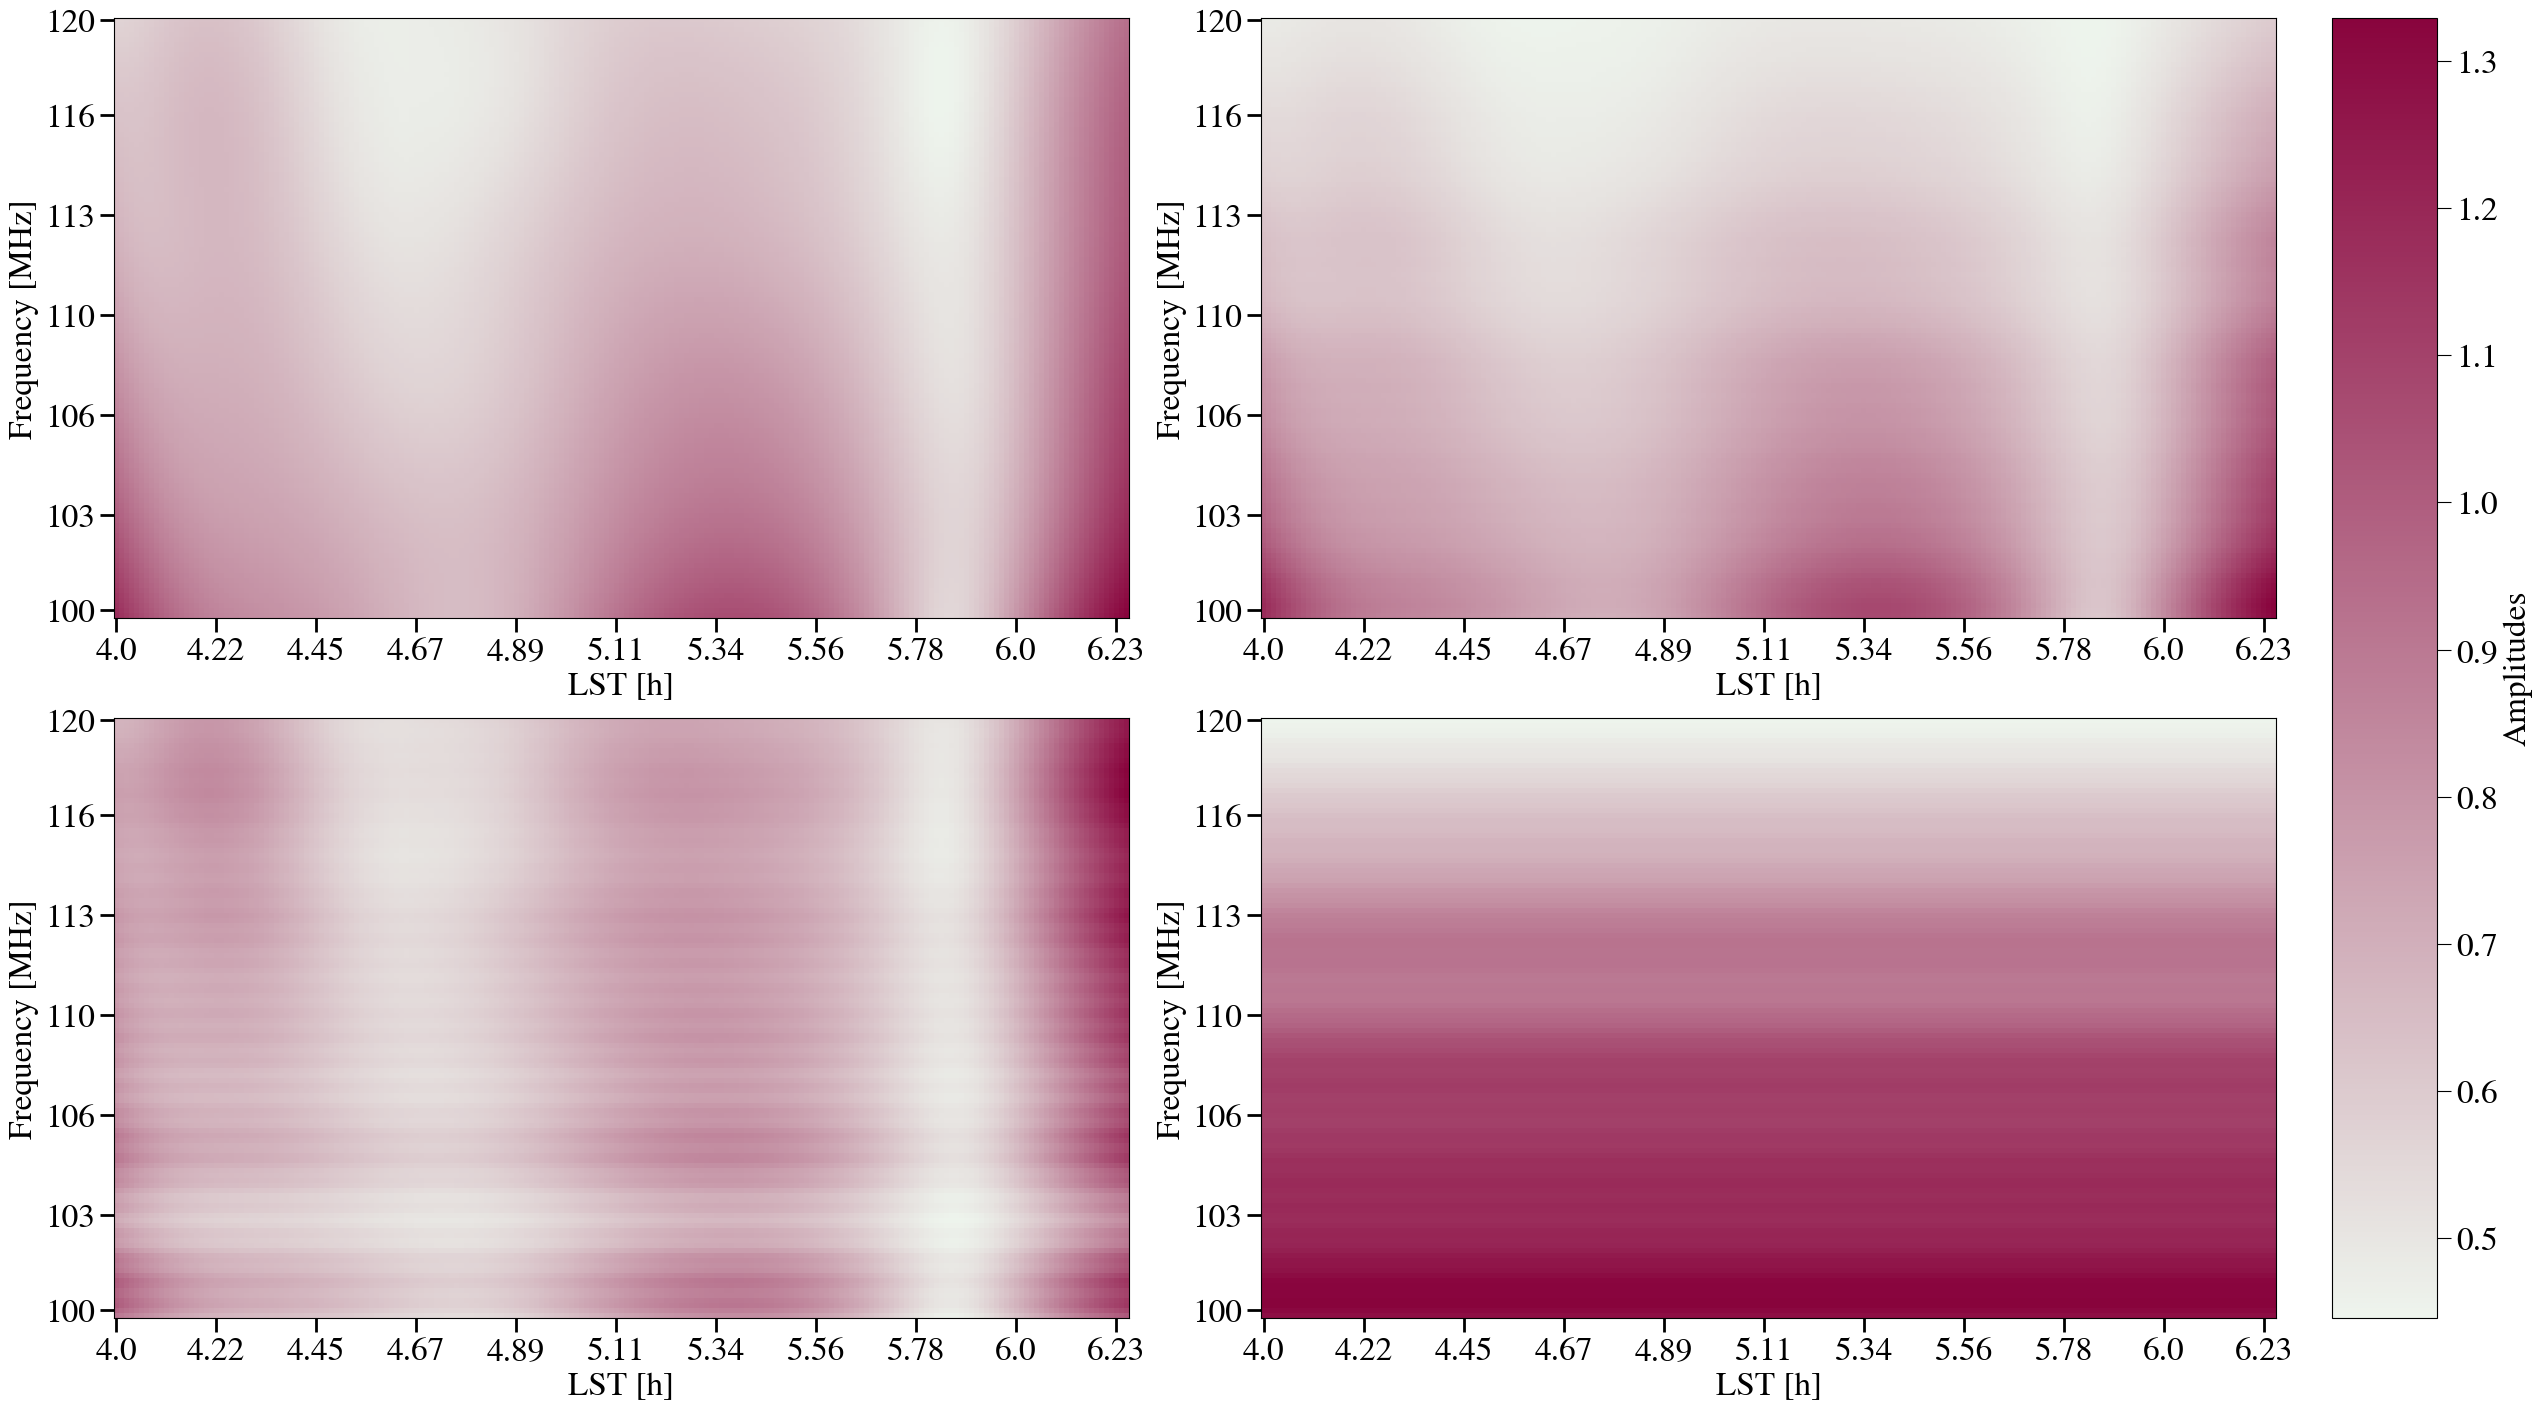

In [96]:
fig = plt.figure(figsize=(30., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.78, 0.65),
    nrows_ncols=(2, 2),
    axes_pad=1,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='all',
    aspect=False,
)
data_arr = np.array([[clean_vis, vis_corr], [vis_corr - clean_vis, vis_corr / clean_vis]])
a = 0
for i in range(2):
    for j in range(2):
        im = axs[a].imshow(np.abs(data_arr[i, j, :, :]).T, cmap=paper_map_pink, origin='lower')
        axs[a].set_ylabel('Frequency [MHz]')
        axs[a].set_xlabel('LST [h]')
        axs[a].tick_params(direction='out', length=6, width=2, colors='black', size=10)
        a += 1
cbar = axs.cbar_axes[0].colorbar(im, label='Amplitudes')
cbar.ax.tick_params(which='both', color='black', labelcolor='black', size=10)
for a in axs:
    a.set_yticks(xticklocs_full, labels=xticklabels_freqs_full)
    a.set_xticks(yticklocs_full, labels=yticklabels_times_full)
# plt.savefig(fig_dir + '/systematics_in_vis_space.pdf', bbox_inches='tight', dpi=300)

---
# Figure 3: Test cases in delay–fringe-rate space

In [97]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_eor = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_eor = np.unique(uvd.lst_array)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_sky = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_sky = np.unique(uvd.lst_array)

eor_true = np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true  = np.load(parent_dir + 'res/npy_data/fg_true.npy')[:Ntimes, :Nfreqs]
data_true_full      = eor_true + fg_true
data_true_dlfr_full = dlfr(data_true_full)

10 0
11 0
12 0
13 0


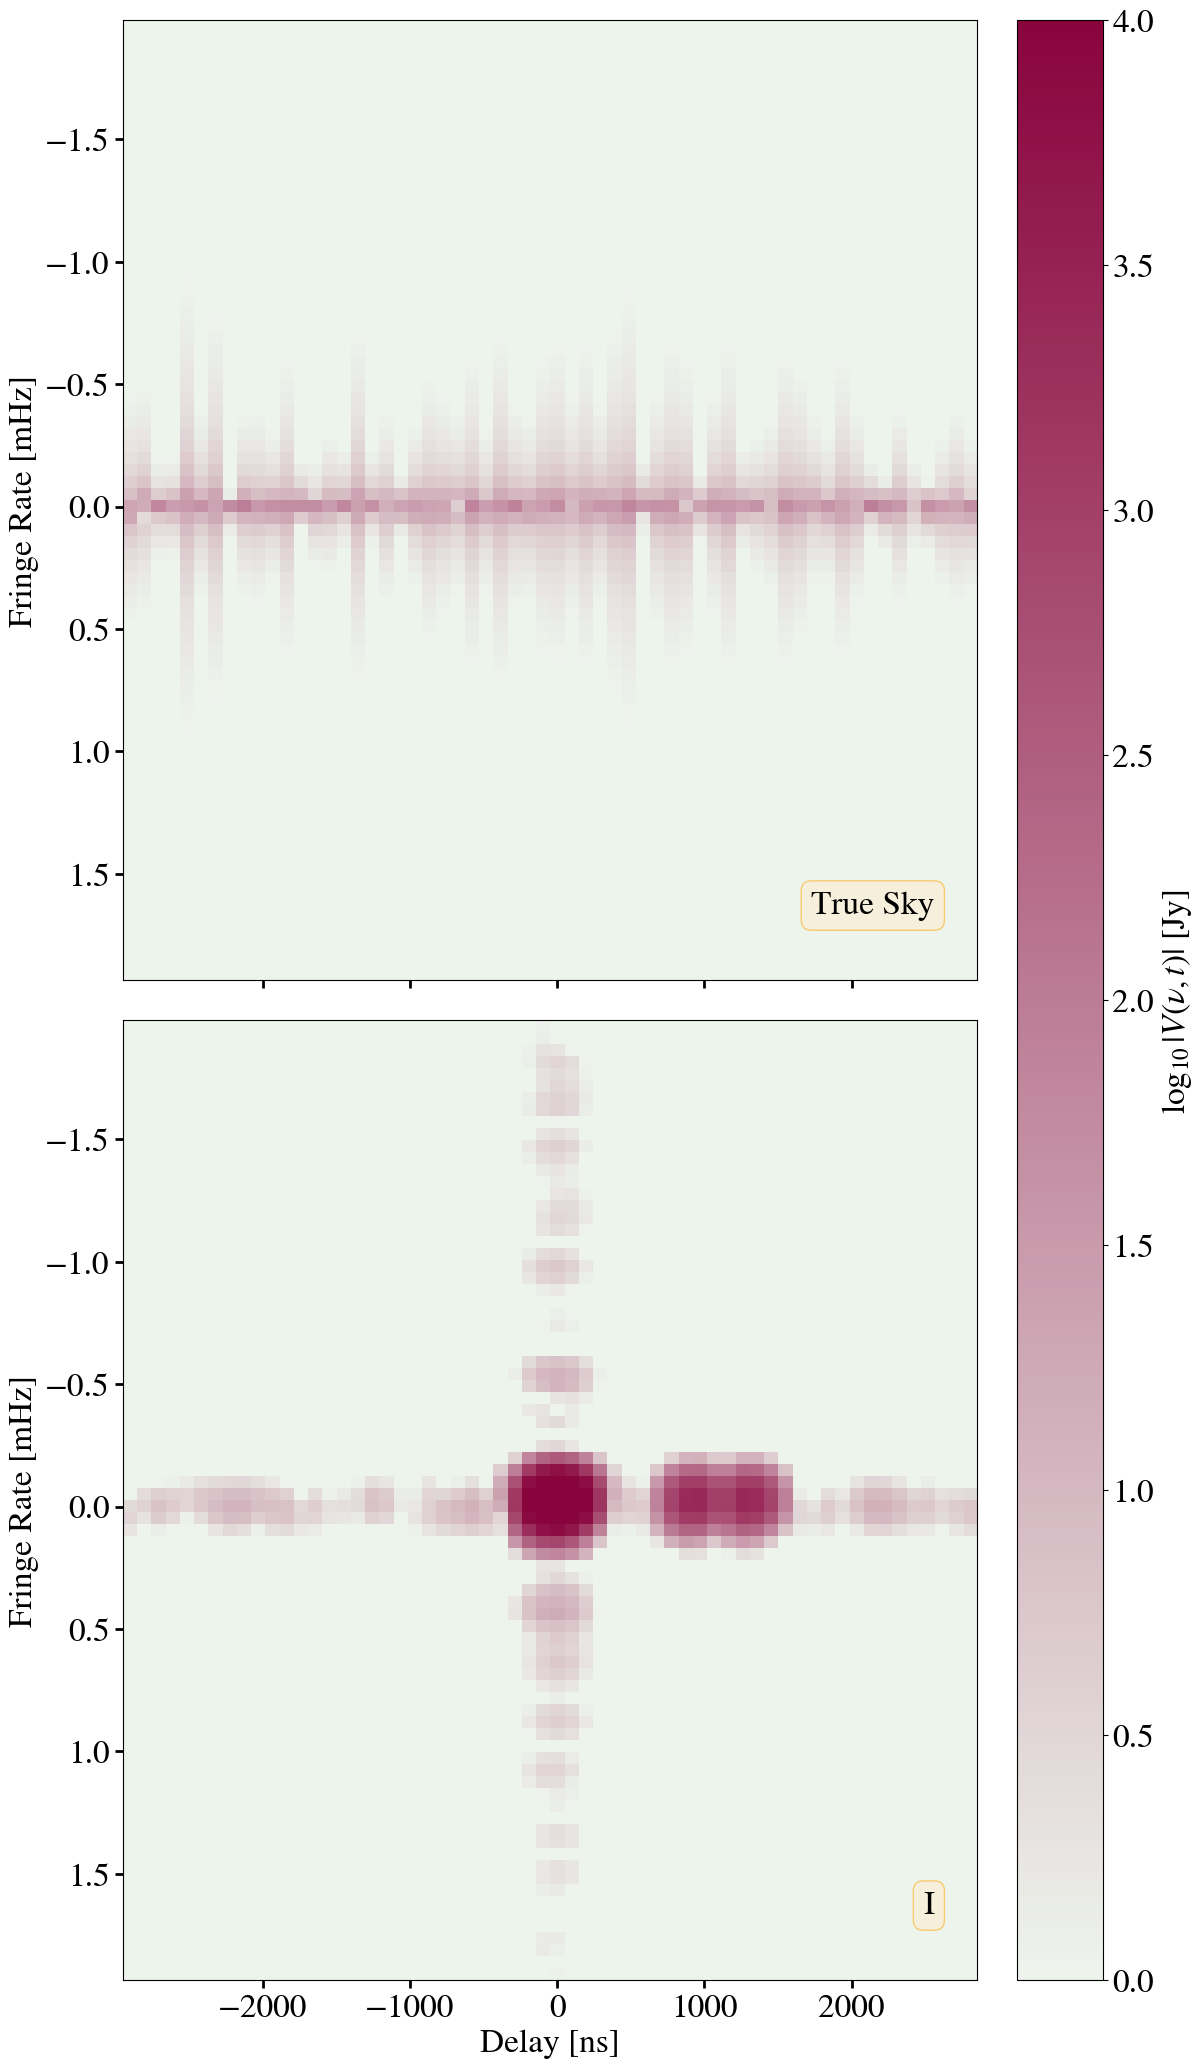

In [98]:
fig = plt.figure(figsize=(10., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),
    nrows_ncols=(2, 1),
    axes_pad=0.4,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

_ = plot_waterfalls(
    eor_true, freqs * 1e6, lsts, fig=fig, ax=axs[0], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all',
    baseline=None, horizon_color='magenta', colorbar_flag=False,
)
axs[0].text(0.95, 0.07, 'True Sky', bbox=bbox, transform=axs[0].transAxes, horizontalalignment='right')

fig_labels = ['I', 'II', 'III']
op = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[case_idx])
sys_model_true = (1 + op @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
total_data_dlfr = dlfr(sys_model_true * data_true_full)
plot_op = plot_waterfalls_from_dlfr(
    total_data_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs[1], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=False,
    baseline=None, horizon_color='magenta',
)
axs[1].text(0.95, 0.07, fig_labels[case_idx], bbox=bbox, transform=axs[1].transAxes, horizontalalignment='right')

axs.cbar_axes[0].colorbar(plot_op, label=r'$\log_{10}|V(\nu, t)|$ [Jy]')
# plt.savefig(fig_dir + '/test_cases_in_dlfr.pdf', bbox_inches='tight', dpi=300)

---
# Single-case analysis (case_idx = `case_idx`)

The cells below load and process data for the single case selected by `case_idx`.

In [99]:
run_version = run_version_arr[case_idx]

fg_true        = np.load(result_dir + run_version + '/fg_true.npy')
fgmodes        = np.load(result_dir + run_version + '/fgmodes.npy')
fg_amps_gcr    = np.load(result_dir + run_version + '/fg-amps.npy')
eor_true       = np.load(result_dir + run_version + '/eor_true.npy')
eor_gcr        = np.load(result_dir + run_version + '/gcr-eor.npy')
ps_sample      = np.load(result_dir + run_version + '/dps-eor.npy')
ln_post        = np.load(result_dir + run_version + '/ln-post.npy')
b_sys_gcr      = np.load(result_dir + run_version + '/b-sys.npy')
sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')
data_true      = np.load(result_dir + run_version + '/data_true.npy')

delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
sky_true     = eor_true + fg_true

# ── Static DLFR quantities ────────────────────────────────────────────────────
sky_true_dlfr       = dlfr(sky_true)
sys_model_true_dlfr = dlfr(sys_model_true)
delta_g_dlfr_true   = dlfr(delta_g_true)
data_true_dlfr      = dlfr(data_true)

# ── Allocate per-iteration arrays (only those needed after the loop) ──────────
ps_fg    = np.empty(ps_sample.shape)
ps_sys   = np.empty(ps_sample.shape)
ps_del_g = np.empty(ps_sample.shape)
ps_data  = np.empty(ps_sample.shape)

sky_dlfr_arr     = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 5 std
fg_dlfr_arr      = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 11 Pearson
delta_g_dlfr_arr = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 6 stats + Fig 11 Pearson

# ── Single-pass Gibbs sample processing ──────────────────────────────────────
print('Processing samples (single case)...')
for i in tqdm(range(Niter)):
    fg_vis = (fgmodes @ fg_amps_gcr[i].T).T
    dg     = (sys_modes_operator @ b_sys_gcr[i]).reshape([Nfreqs, Ntimes]).T
    dg_d   = dlfr(dg)

    ps_fg[i]    = calc_ps((fgmodes[:, :Nfgmodes] @ fg_amps_gcr[i].T).T)
    ps_sys[i]   = calc_ps(1 + dg)
    ps_del_g[i] = calc_ps(dg)
    ps_data[i]  = calc_ps((1 + dg) * (eor_gcr[i] + fg_vis))

    sky_dlfr_arr[i]     = dlfr(eor_gcr[i] + fg_vis)
    fg_dlfr_arr[i]      = dlfr(fg_vis)
    delta_g_dlfr_arr[i] = dg_d

# ── Power spectrum statistics ─────────────────────────────────────────────────
eor_pspec_avg   = np.mean(ps_sample, axis=0)
fg_pspec_avg    = np.mean(ps_fg, axis=0)
sys_pspec_avg   = np.mean(ps_sys, axis=0)
data_pspec_avg  = np.mean(ps_data, axis=0)
delg_pspec_avg  = np.mean(ps_del_g, axis=0)

eor_pspec_true  = calc_ps(eor_true)
fg_pspec_true   = calc_ps(fg_true)
sys_pspec_true  = calc_ps(sys_model_true)
n_pspec         = calc_ps(n.T)
data_pspec_true = calc_ps(data_true)
b_sys_mean      = np.mean(b_sys_gcr, axis=0)

# ── DLFR statistics ───────────────────────────────────────────────────────────
delta_g_dlfr_mean   = delta_g_dlfr_arr.mean(axis=0)
delta_g_dlfr_std    = np.std(delta_g_dlfr_arr, axis=0)
sys_model_dlfr_mean = dlfr_ones + delta_g_dlfr_mean   # linearity: DLFR(1+dg) = dlfr_ones + DLFR(dg)
mean_sky_dlfr       = sky_dlfr_arr.mean(axis=0)

Processing samples (single case)...


100%|██████████| 100000/100000 [01:10<00:00, 1409.65it/s]


## Case data (Figures 4, 5 v2, 6 v2, 11)

Directly derives DLFR statistics for the selected case (`case_idx`) from the
arrays already computed in the single-case processing cell above.

In [100]:
# Single-case version: all *_all lists contain only the selected case.
# Arrays reused directly from the single-case processing cell.

data_true_dlfr_all    = [data_true_dlfr]
sky_true_dlfr_all     = [sky_true_dlfr]
mean_sky_dlfr_all     = [mean_sky_dlfr]
std_sky_dlfr_all      = [np.std(sky_dlfr_arr, axis=0)]
res_sky_dlfr_all      = [sky_true_dlfr - mean_sky_dlfr]
delta_g_dlfr_true_all = [delta_g_dlfr_true]
delta_g_dlfr_mean_all = [delta_g_dlfr_mean]
delta_g_dlfr_std_all  = [delta_g_dlfr_std]
res_sys_dlfr_all      = [sys_model_true_dlfr - sys_model_dlfr_mean]
corr_maps             = [plot_crosscor_pearson(fg_dlfr_arr, dlfr_ones[np.newaxis] + delta_g_dlfr_arr)]

print('Done.')

Done.


---
# Figure 4: Data vs sky (single case)

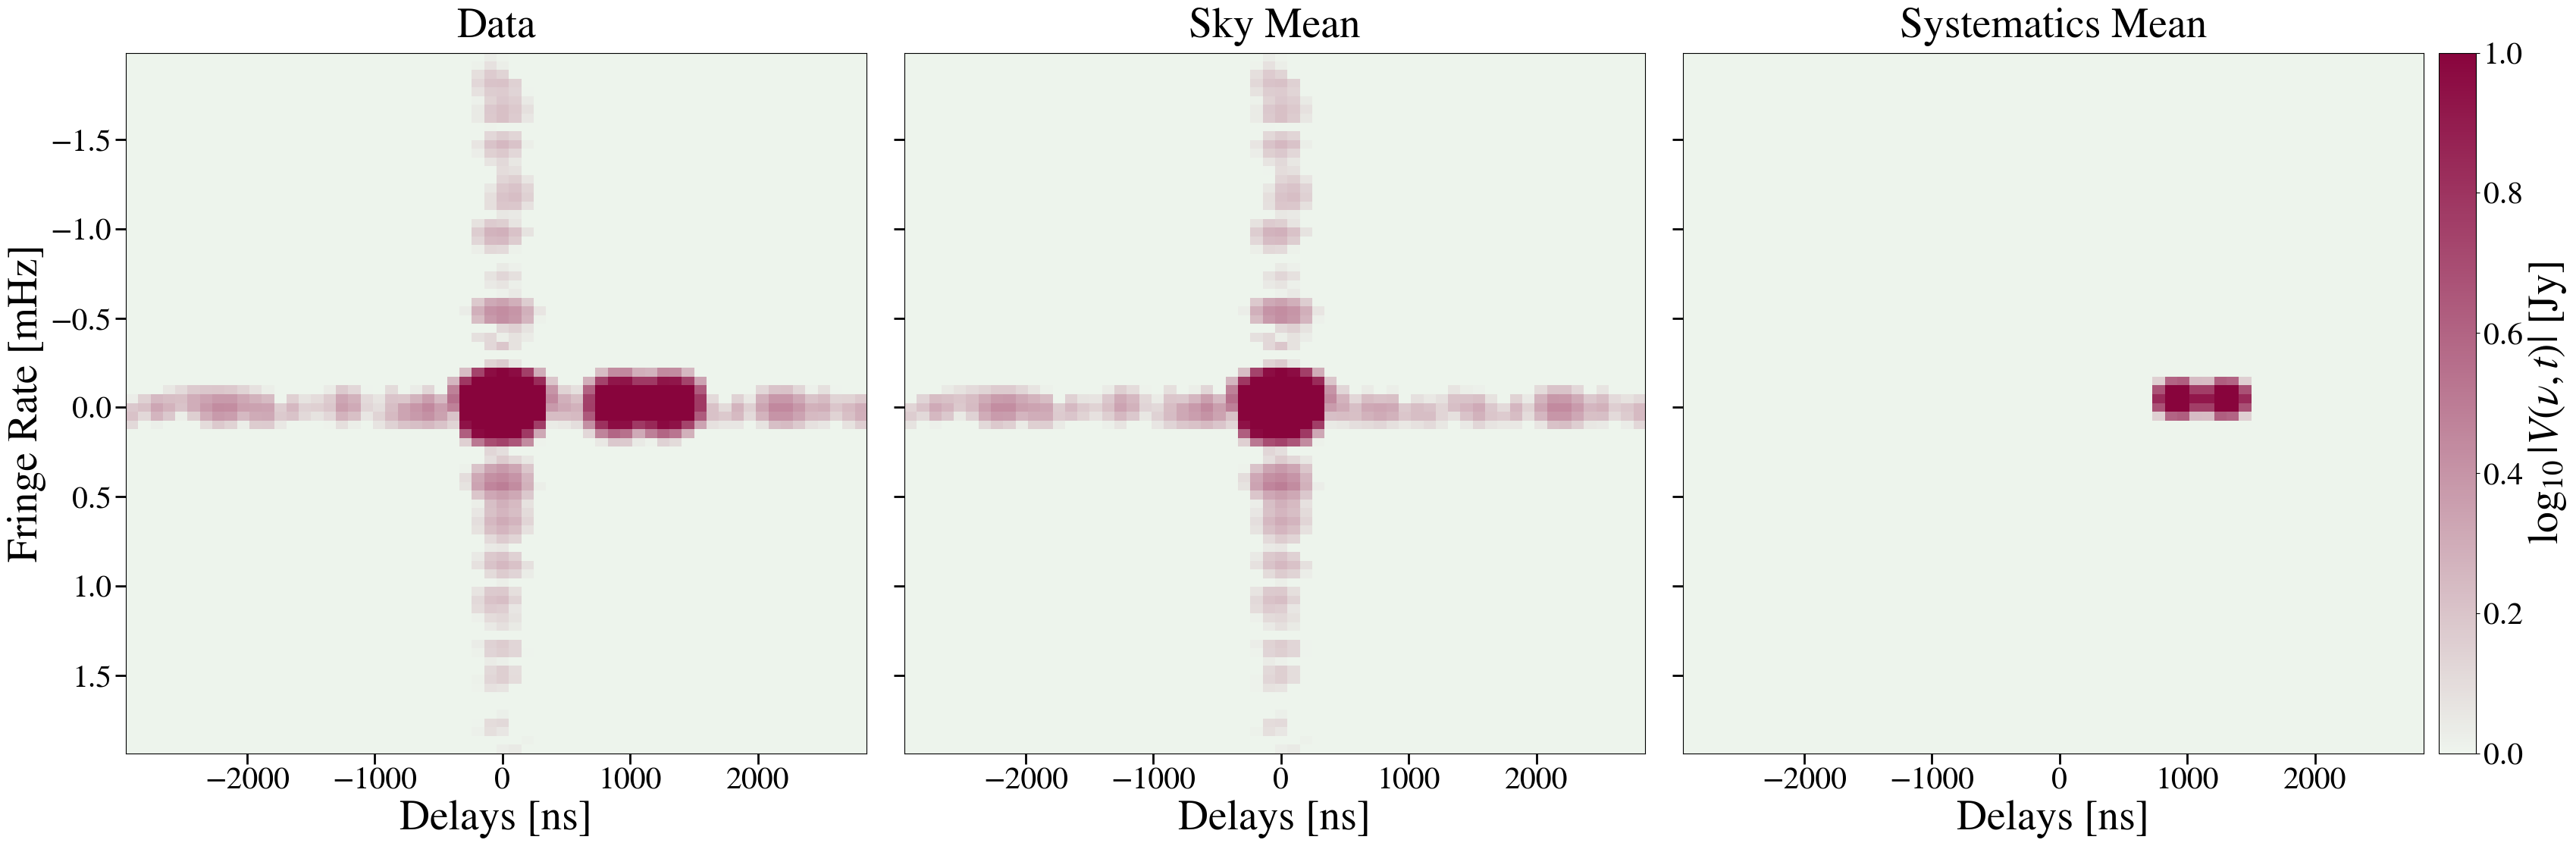

In [101]:
fig = plt.figure(figsize=(40, 12))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

im0 = plot_waterfalls_from_dlfr(
    data_true_dlfr_all[0], freqs * 1e6, lsts, fig=fig, ax=ax[0], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)
im1 = plot_waterfalls_from_dlfr(
    mean_sky_dlfr_all[0], freqs * 1e6, lsts, fig=fig, ax=ax[1], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)
im2 = plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean_all[0], freqs * 1e6, lsts, fig=fig, ax=ax[2], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)

fig_titles = ['Data', 'Sky Mean', 'Systematics Mean']
for i, a in enumerate(ax):
    a.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=30)
    a.set_xlabel('Delays [ns]', fontsize=40)
    a.set_ylabel('Fringe Rate [mHz]', fontsize=40)
    a.set_title(fig_titles[i], fontsize=40, pad=15)
cbar = ax.cbar_axes[0].colorbar(im2)
cbar.set_label(r'$\log_{10}|V(\nu, t)|$ [Jy]', size=40)
cbar.ax.tick_params(labelsize=30)
# plt.savefig(fig_dir + '/data_vs_sky_2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 5: Result waterfalls (single case)

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

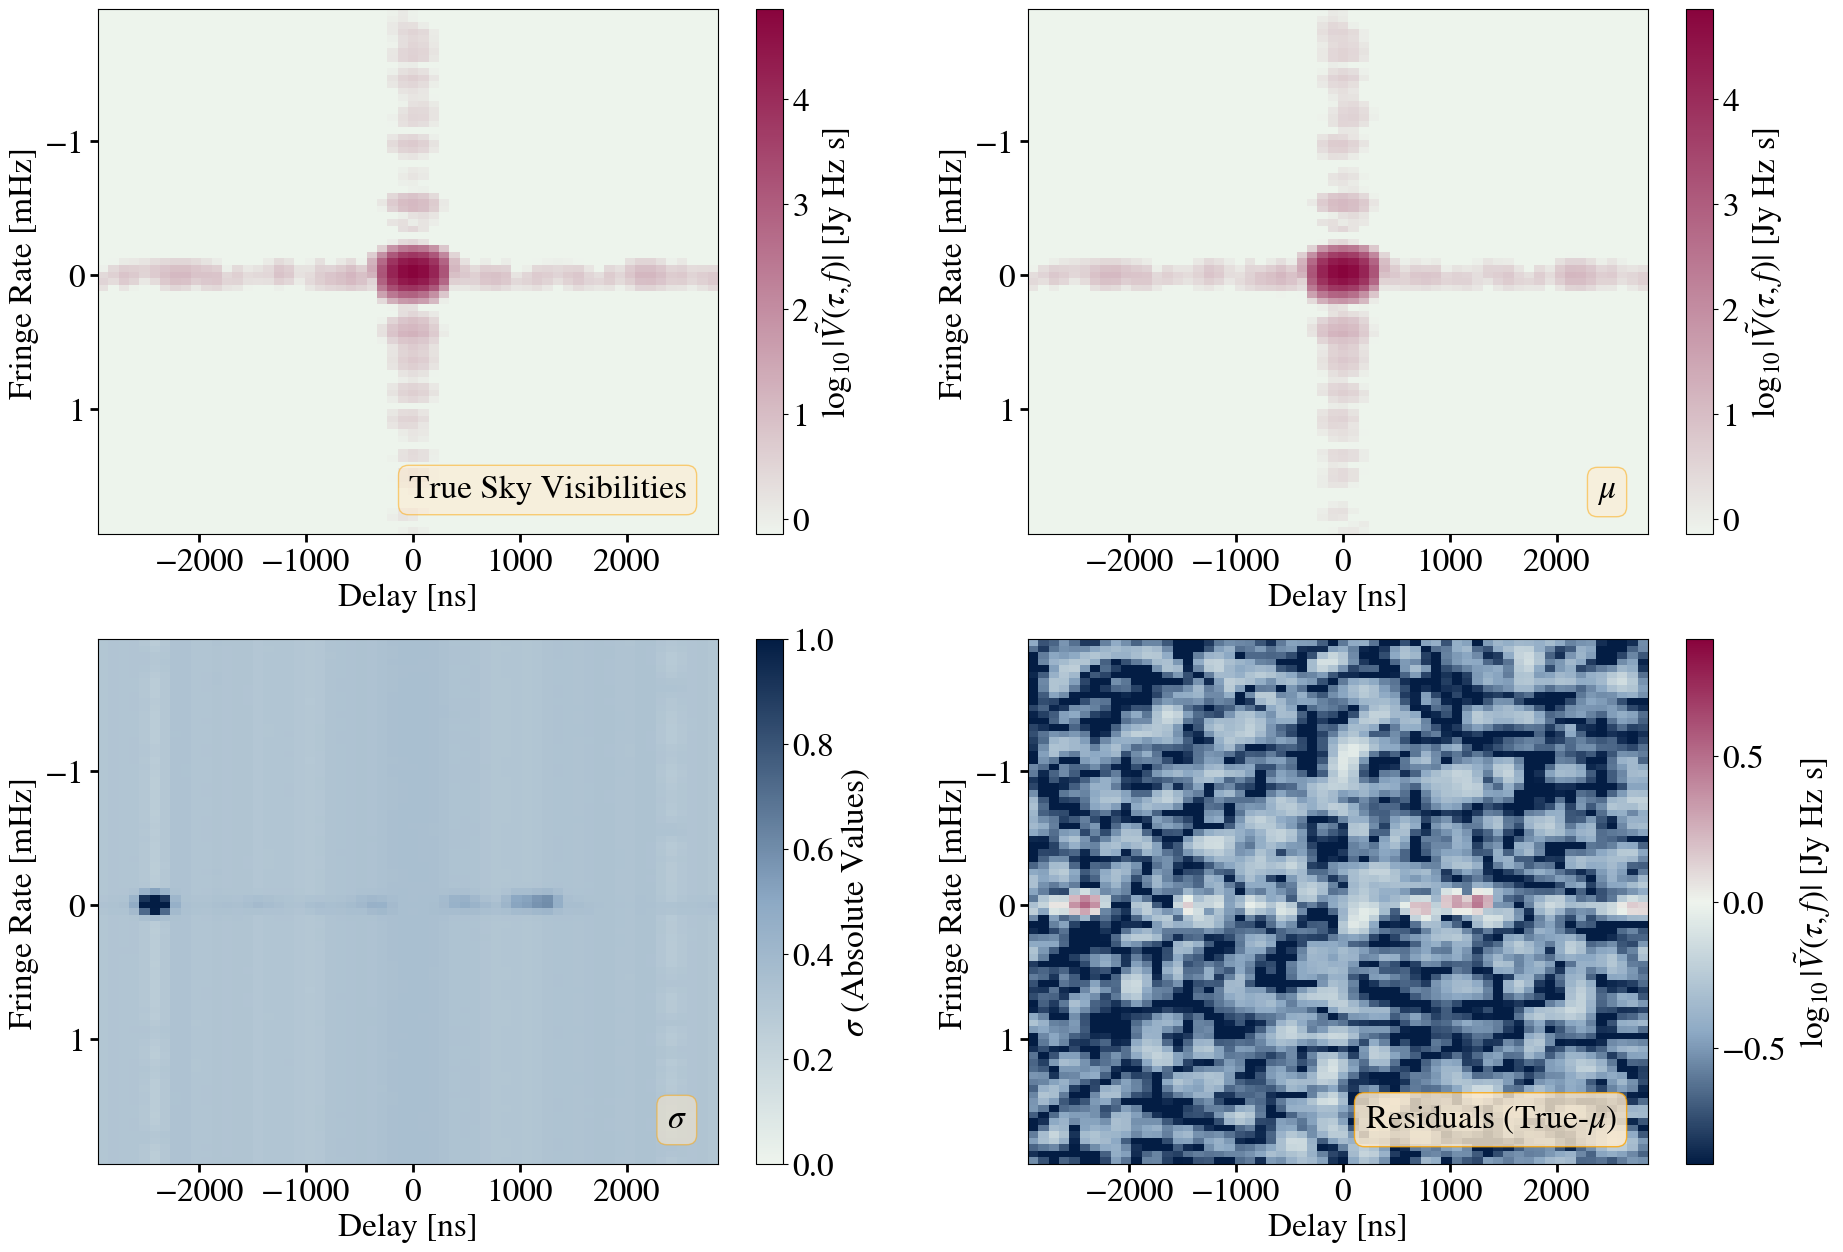

In [102]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    sky_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Sky Visibilities', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    np.std(sky_dlfr_arr, axis=0), freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sky_true_dlfr - mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[3], mode='log',
    vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir + '/result_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figures 5 & 6 v2: Single-case result waterfalls

Versions of Figures 5 and 6 for the single case selected by `case_idx`.
Rows = True / Mean / Std / Residuals.

In [103]:
# Statistics for the v2 figures derived from single-case processing above.
case_labels_v2 = [['Case I', 'Case II', 'Case III'][case_idx]]
row_labels_v2  = ['True', r'$\mu$', r'$\sigma$', 'Residuals']

### Figure 5 v2: Sky result waterfalls (single case)

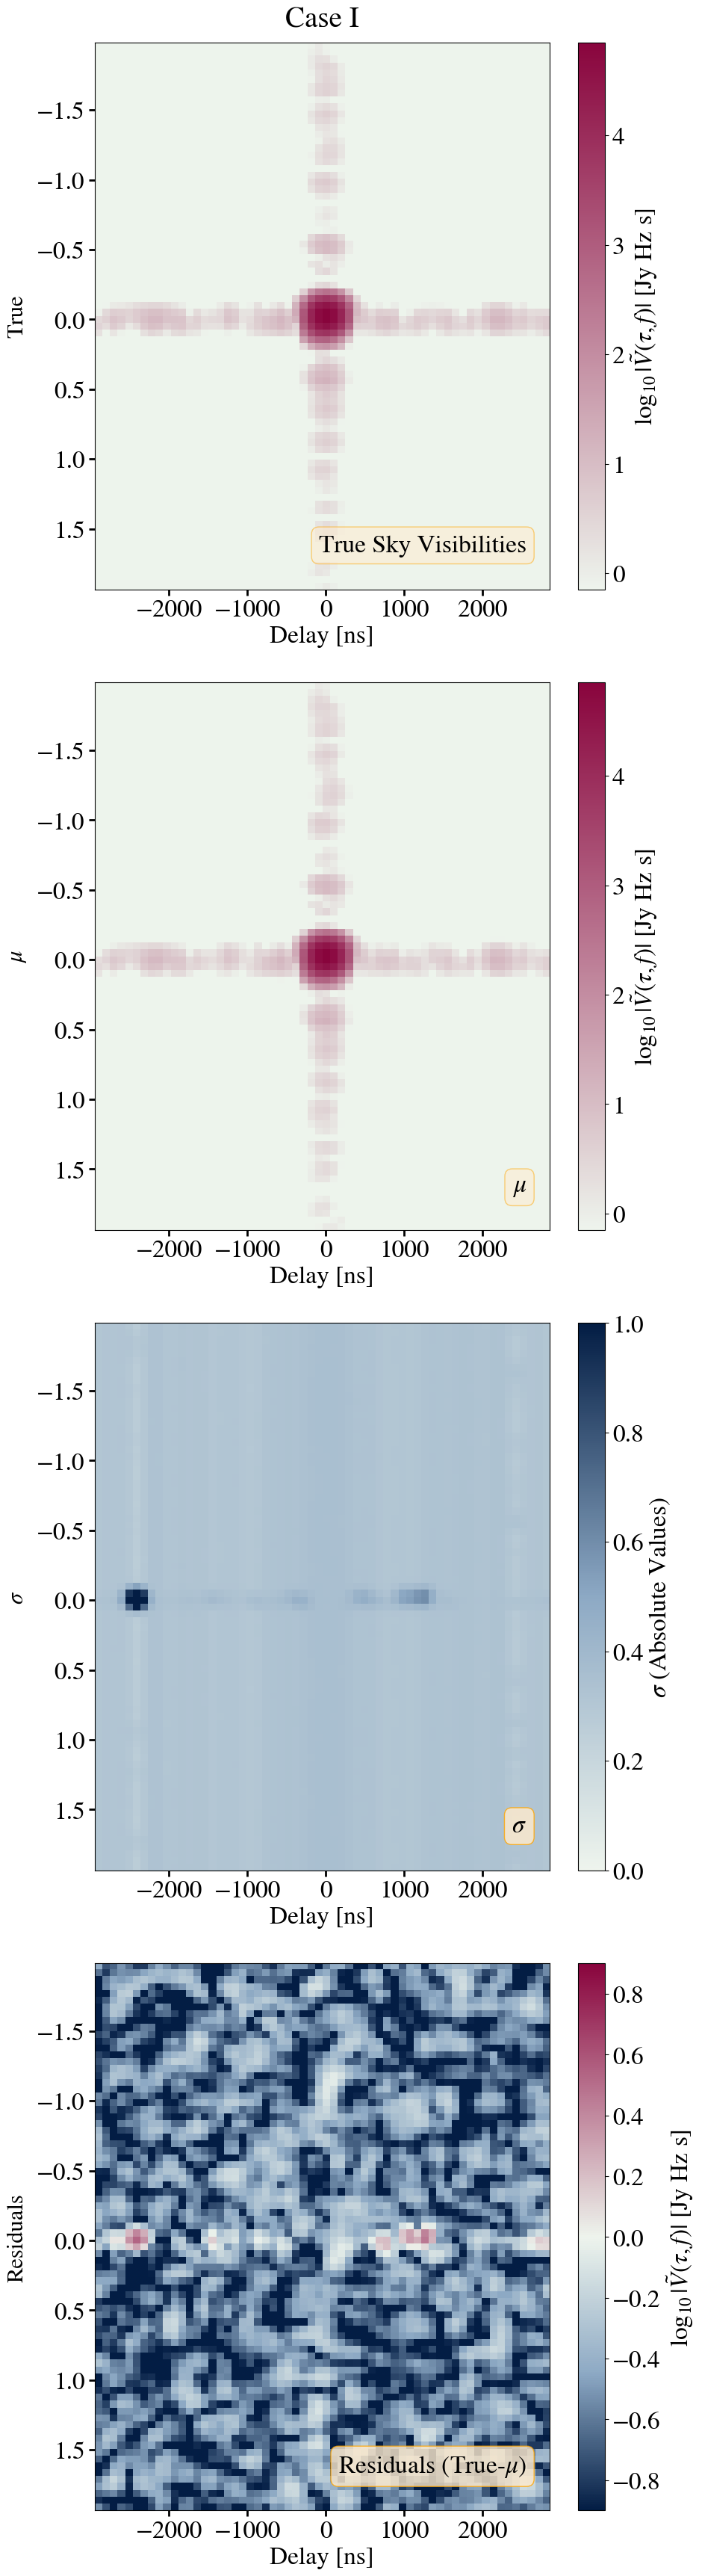

In [104]:
# Figure 5 v2: Sky result waterfalls – single case
# Rows: True | Mean | Std | Residuals

annots_sky_v2 = [
    'True Sky Visibilities',
    r'$\mu$',
    r'$\sigma$',
    'Residuals (True-' + r'$\mu$' + ')',
]

fig5v2, axs5v2 = plt.subplots(4, 1, figsize=(10, 35))

# Row 0: True
plot_waterfalls_from_dlfr(
    sky_true_dlfr_all[0], freqs * 1e6, lsts,
    fig=fig5v2, ax=axs5v2[0], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5,
    limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
# Row 1: Mean
plot_waterfalls_from_dlfr(
    mean_sky_dlfr_all[0], freqs * 1e6, lsts,
    fig=fig5v2, ax=axs5v2[1], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5,
    limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
# Row 2: Std
plot_waterfalls_from_dlfr(
    std_sky_dlfr_all[0], freqs * 1e6, lsts,
    fig=fig5v2, ax=axs5v2[2], mode='abs',
    vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None,
    limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
    cbar_label=r'$\sigma$ (Absolute Values)',
)
# Row 3: Residuals
plot_waterfalls_from_dlfr(
    res_sky_dlfr_all[0], freqs * 1e6, lsts,
    fig=fig5v2, ax=axs5v2[3], mode='log',
    vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None,
    limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)

# Row y-labels and per-panel annotations
for row, lbl in enumerate(row_labels_v2):
    axs5v2[row].set_ylabel(lbl, fontsize=22, labelpad=8)
bbox_uses = [bbox, bbox, bbox_res, bbox_res]
for row in range(4):
    axs5v2[row].text(
        0.95, 0.07, annots_sky_v2[row], bbox=bbox_uses[row],
        transform=axs5v2[row].transAxes, horizontalalignment='right',
    )

axs5v2[0].set_title(case_labels_v2[0], fontsize=28, pad=15)
fig5v2.tight_layout()
# plt.savefig(fig_dir + '/result_waterfalls_v2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 6: Systematics result waterfalls (single case)

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

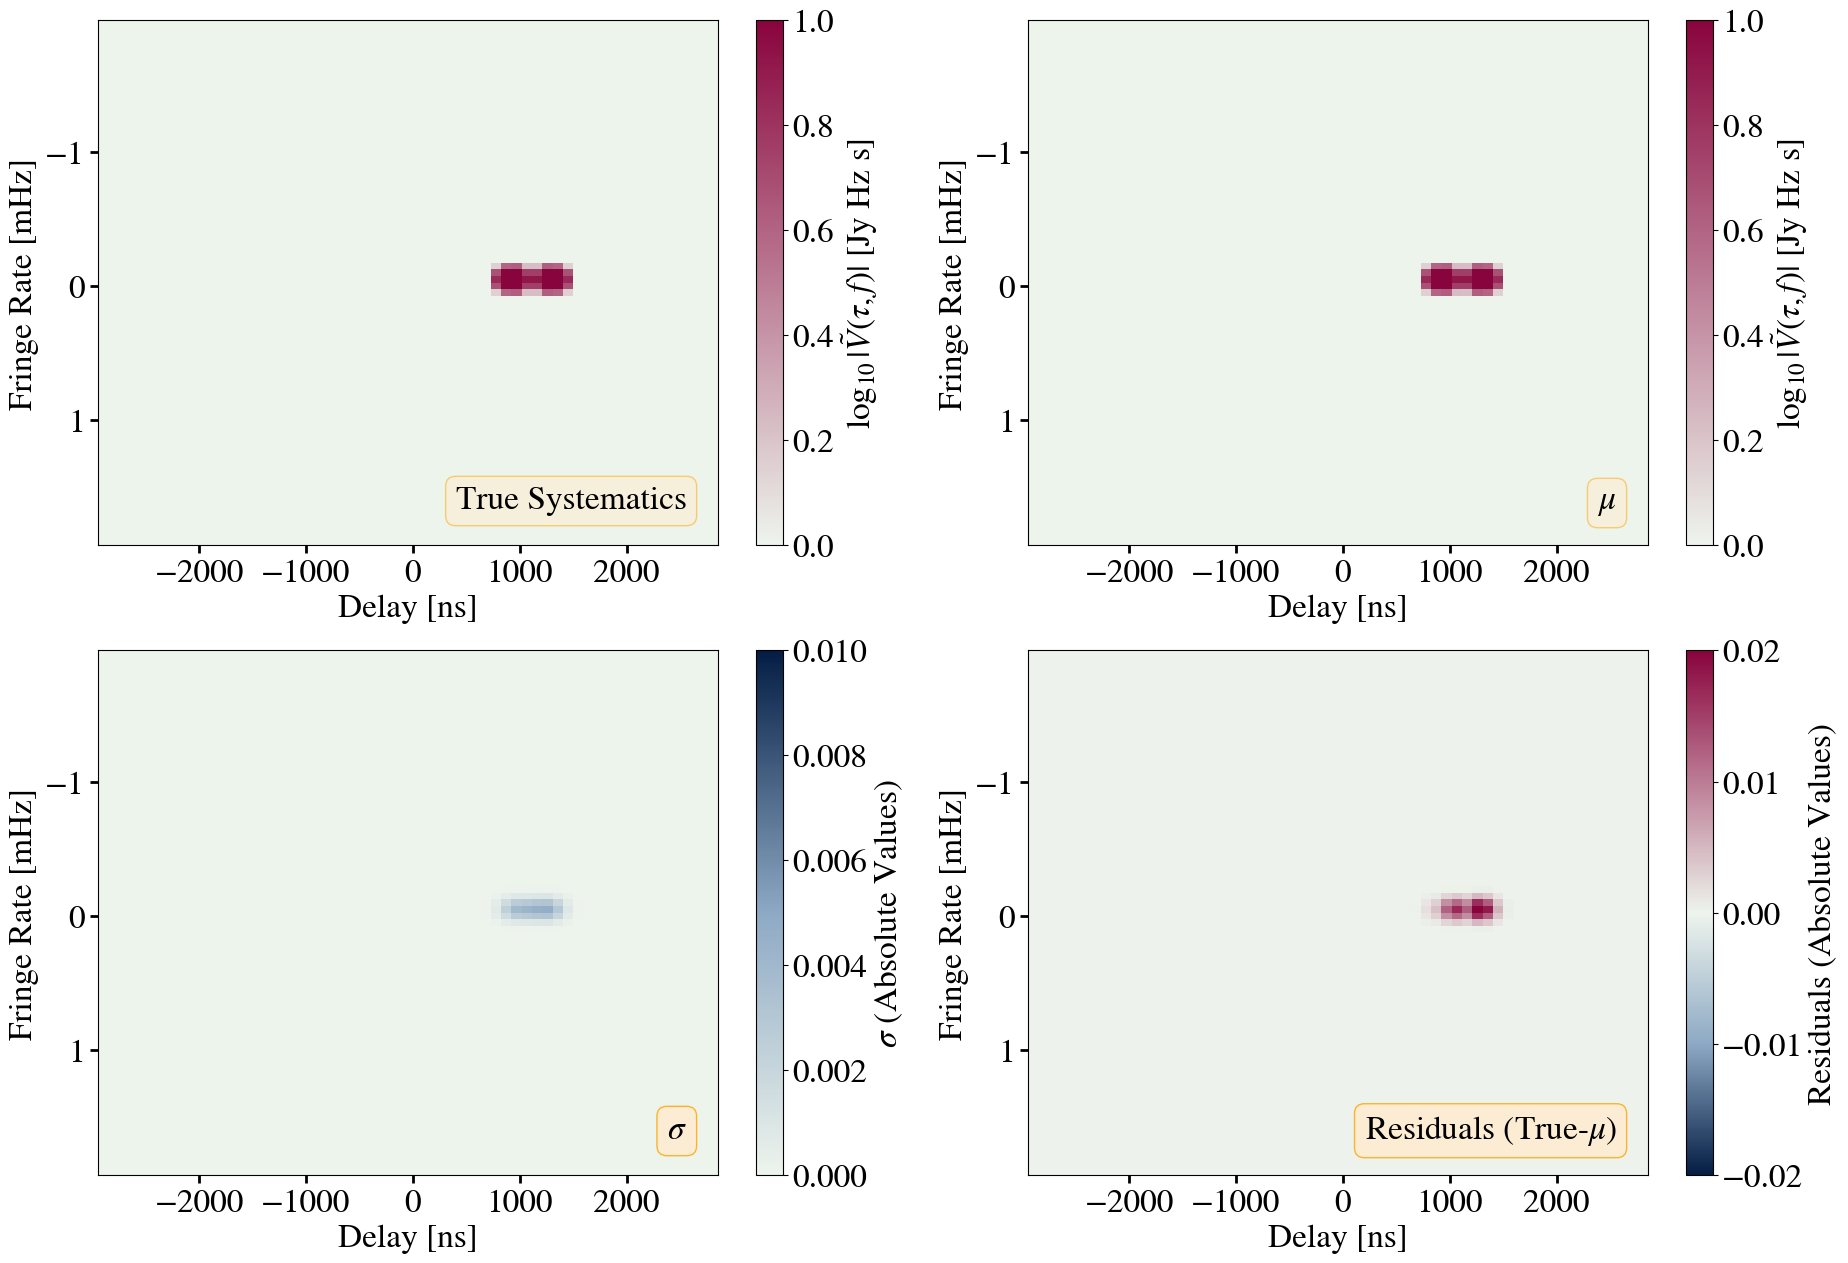

In [105]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    delta_g_dlfr_true, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Systematics', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_std, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sys_model_true_dlfr - sys_model_dlfr_mean, freqs * 1e6, lsts,
    fig=fig, ax=axs.flatten()[3], mode='abs', vmin=-0.02, vmax=0.02, cmap=paper_map,
    dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label='Residuals (Absolute Values)',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls.pdf', bbox_inches='tight', dpi=300)

### Figure 6 v2: Systematics result waterfalls (single case)

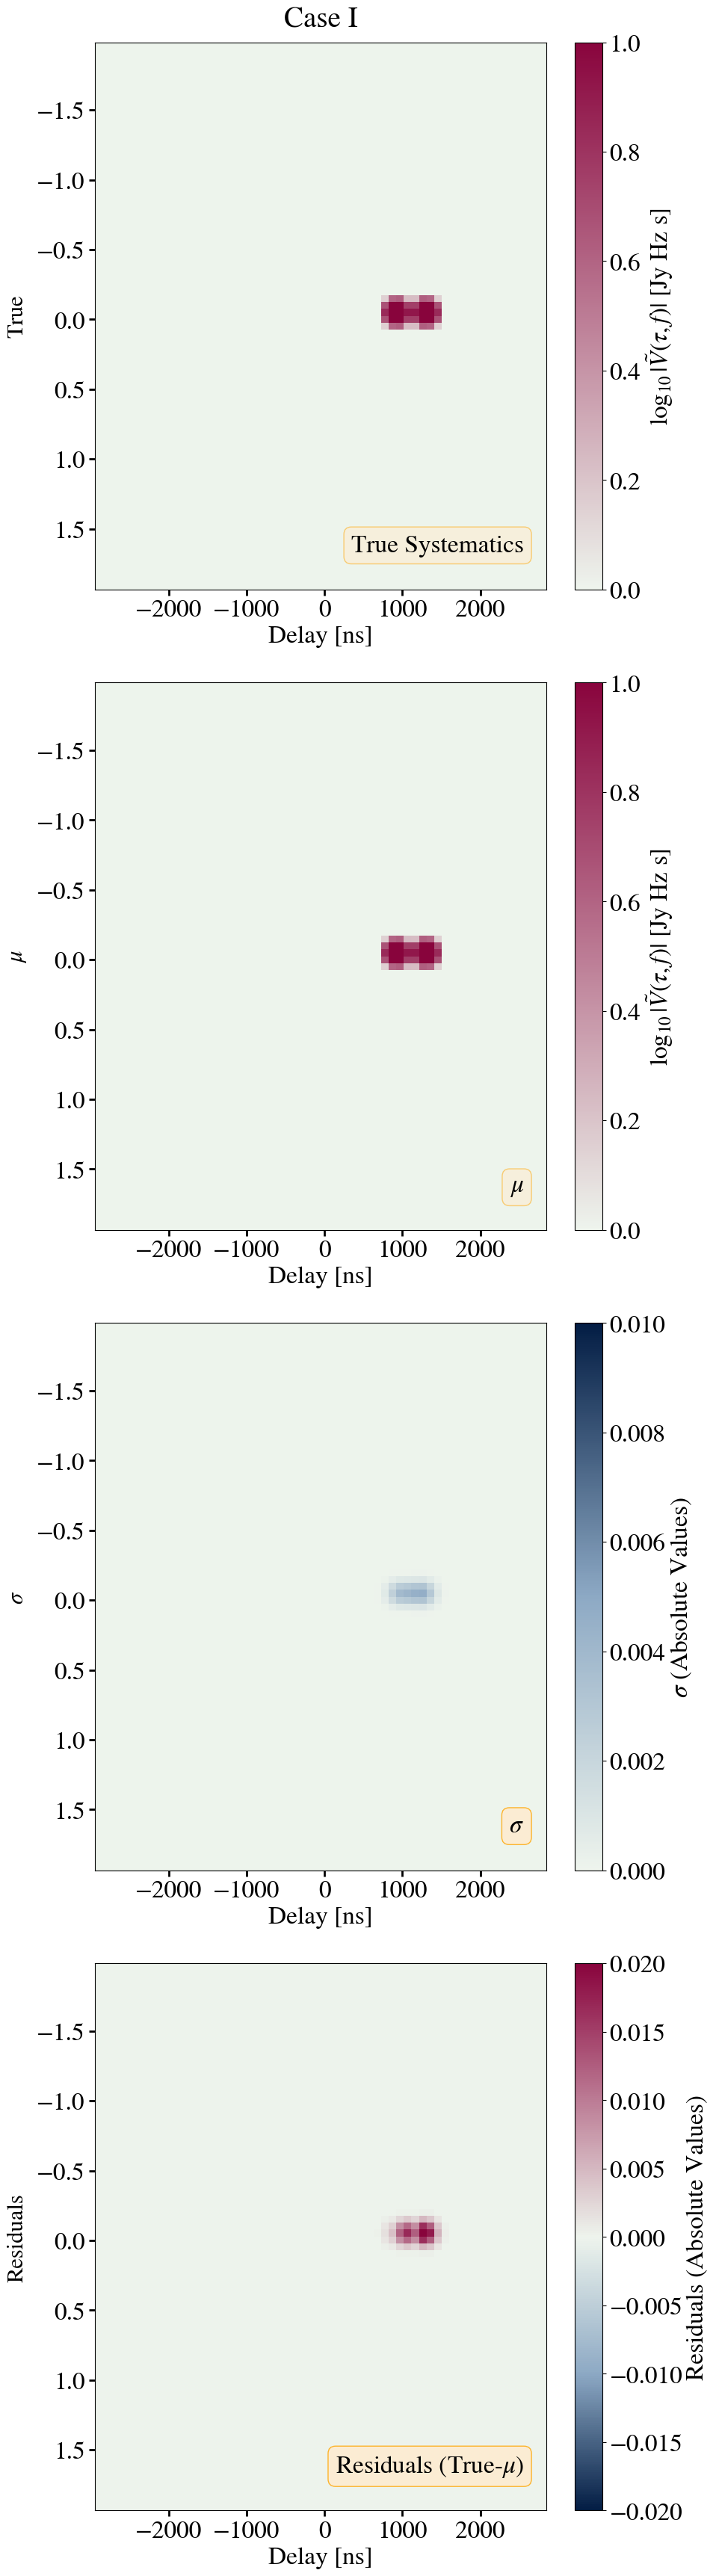

In [106]:
# Figure 6 v2: Systematics result waterfalls – single case
# Rows: True | Mean | Std | Residuals

annots_sys_v2 = [
    'True Systematics',
    r'$\mu$',
    r'$\sigma$',
    'Residuals (True-' + r'$\mu$' + ')',
]

fig6v2, axs6v2 = plt.subplots(4, 1, figsize=(10, 35))

# Row 0: True
plot_waterfalls_from_dlfr(
    delta_g_dlfr_true_all[0], freqs * 1e6, lsts,
    fig=fig6v2, ax=axs6v2[0], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5,
    limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
# Row 1: Mean
plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean_all[0], freqs * 1e6, lsts,
    fig=fig6v2, ax=axs6v2[1], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5,
    limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
# Row 2: Std
plot_waterfalls_from_dlfr(
    delta_g_dlfr_std_all[0], freqs * 1e6, lsts,
    fig=fig6v2, ax=axs6v2[2], mode='abs',
    vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None,
    limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
    cbar_label=r'$\sigma$ (Absolute Values)',
)
# Row 3: Residuals
plot_waterfalls_from_dlfr(
    res_sys_dlfr_all[0], freqs * 1e6, lsts,
    fig=fig6v2, ax=axs6v2[3], mode='abs',
    vmin=-0.02, vmax=0.02, cmap=paper_map,
    dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
    cbar_label='Residuals (Absolute Values)',
)

# Row y-labels and per-panel annotations
for row, lbl in enumerate(row_labels_v2):
    axs6v2[row].set_ylabel(lbl, fontsize=22, labelpad=8)
bbox_uses = [bbox, bbox, bbox_res, bbox_res]
for row in range(4):
    axs6v2[row].text(
        0.95, 0.07, annots_sys_v2[row], bbox=bbox_uses[row],
        transform=axs6v2[row].transAxes, horizontalalignment='right',
    )

axs6v2[0].set_title(case_labels_v2[0], fontsize=28, pad=15)
fig6v2.tight_layout()
# plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls_v2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 7: Fractional errors by component (single case)

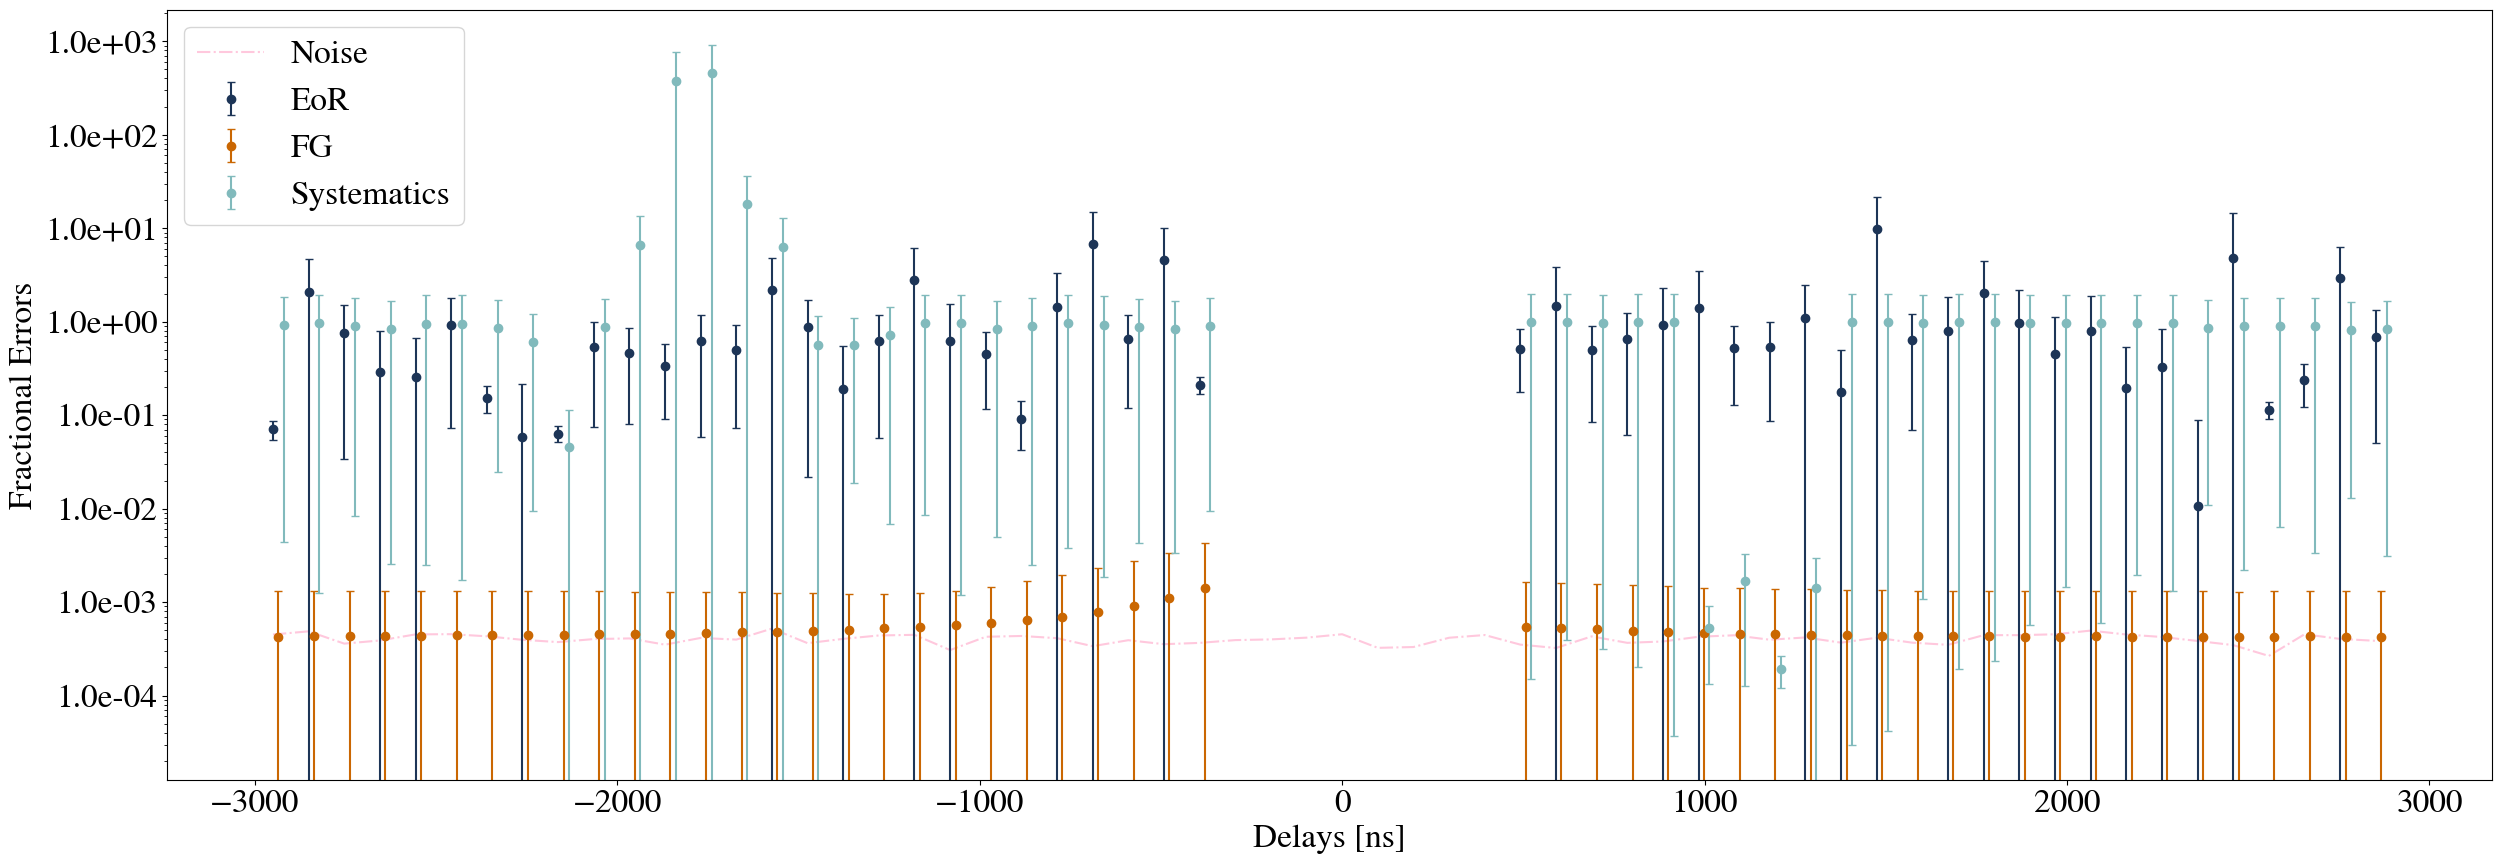

In [107]:
fig, axs = plt.subplots(1, 1, figsize=(30, 10))

data_arr_errs = [
    (eor_pspec_true - ps_sample) / eor_pspec_true,
    (fg_pspec_true  - ps_fg)     / fg_pspec_true,
    (sys_pspec_true - ps_sys)    / sys_pspec_true,
]
plot_arr = [d.mean(axis=0) for d in data_arr_errs]
fig_labels_err = ['EoR', 'FG', 'Systematics', 'Noise']

rm   = np.arange(27, 35)
keep = np.ones(len(plot_arr[0]), dtype=bool)
keep[rm] = False

axs.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], label=fig_labels_err[-1])

for i in range(3):
    pa = plot_arr[i][keep]
    da = data_arr_errs[i][:, keep]
    std  = np.std(np.abs(da), axis=0)
    errs = np.vstack((pa - std, std - pa))
    axs.errorbar(
        delays[keep].value + (i * 15), np.abs(pa),
        yerr=np.abs(errs), fmt='o', color=colors[i], label=fig_labels_err[i], capsize=3,
    )
    axs.legend()

axs.set_yscale('log')
axs.set_xlabel('Delays [ns]')
axs.set_ylabel('Fractional Errors')
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
# plt.savefig(fig_dir + '/errors_components.pdf', bbox_inches='tight', dpi=300)

## Figure 7 v2: Fractional errors by component – single case

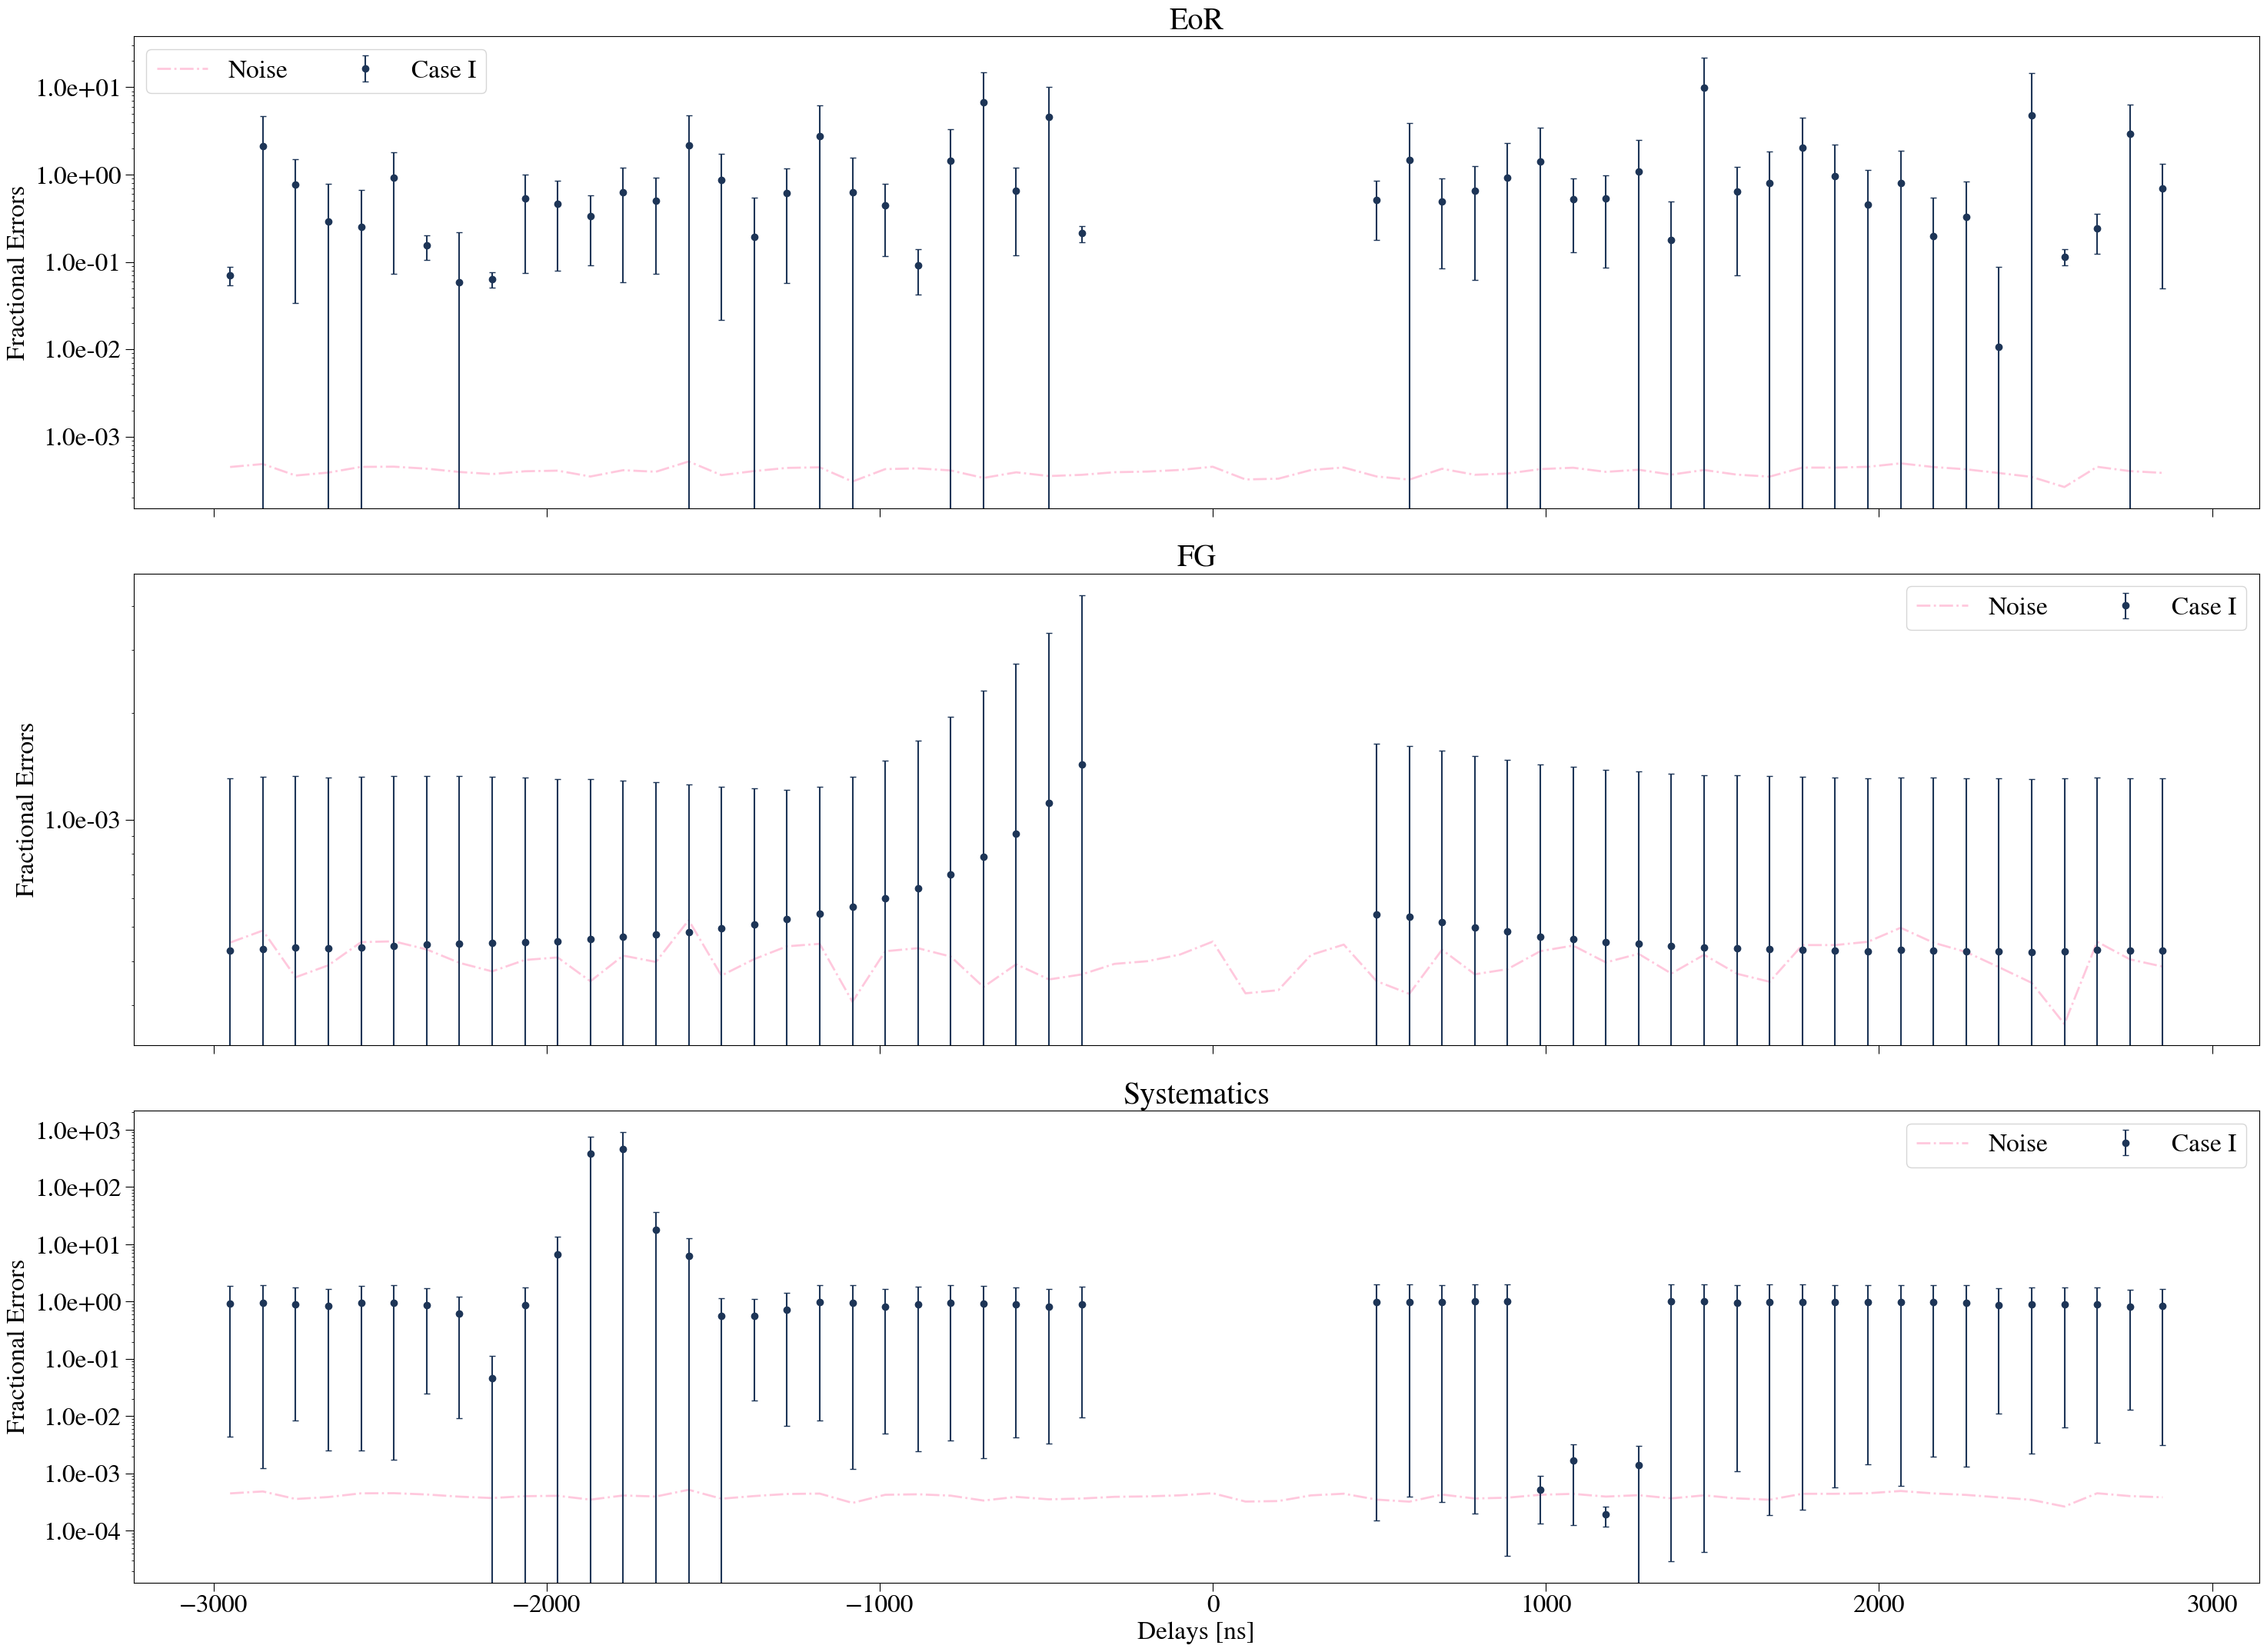

In [108]:
# Rows: EoR  |  Foregrounds  |  Systematics  (single case)
# Reuses ps_sample, ps_fg, ps_sys computed in the single-case processing cell.

component_labels = ['EoR', 'FG', 'Systematics']

rm   = np.arange(27, 35)
keep = np.ones(Nfreqs, dtype=bool)
keep[rm] = False

ps_all_by_comp   = [ps_sample, ps_fg, ps_sys]
ps_true_by_comp  = [eor_pspec_true, fg_pspec_true, sys_pspec_true]

fig7v2, axs7v2 = plt.subplots(3, 1, figsize=(30, 22), sharex=True)

for row, comp in enumerate(component_labels):
    ax = axs7v2[row]
    ax.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], lw=2, label='Noise')

    errs_c = (ps_true_by_comp[row] - ps_all_by_comp[row]) / ps_true_by_comp[row]
    pa     = errs_c.mean(axis=0)[keep]
    std    = np.std(np.abs(errs_c), axis=0)[keep]
    errs   = np.vstack((pa - std, std - pa))
    ax.errorbar(
        delays[keep].value, np.abs(pa), yerr=np.abs(errs),
        fmt='o', color=colors[0], label=case_labels_v2[0],
        capsize=3, elinewidth=1.5,
    )

    ax.set_yscale('log')
    ax.set_ylabel('Fractional Errors')
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
    ax.set_title(comp)
    ax.legend(ncol=2)
    ax.tick_params(length=8)

axs7v2[-1].set_xlabel('Delays [ns]')
fig7v2.tight_layout()
# plt.savefig(fig_dir + '/errors_components_v2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 8: Corner plot of b_sys (single case)

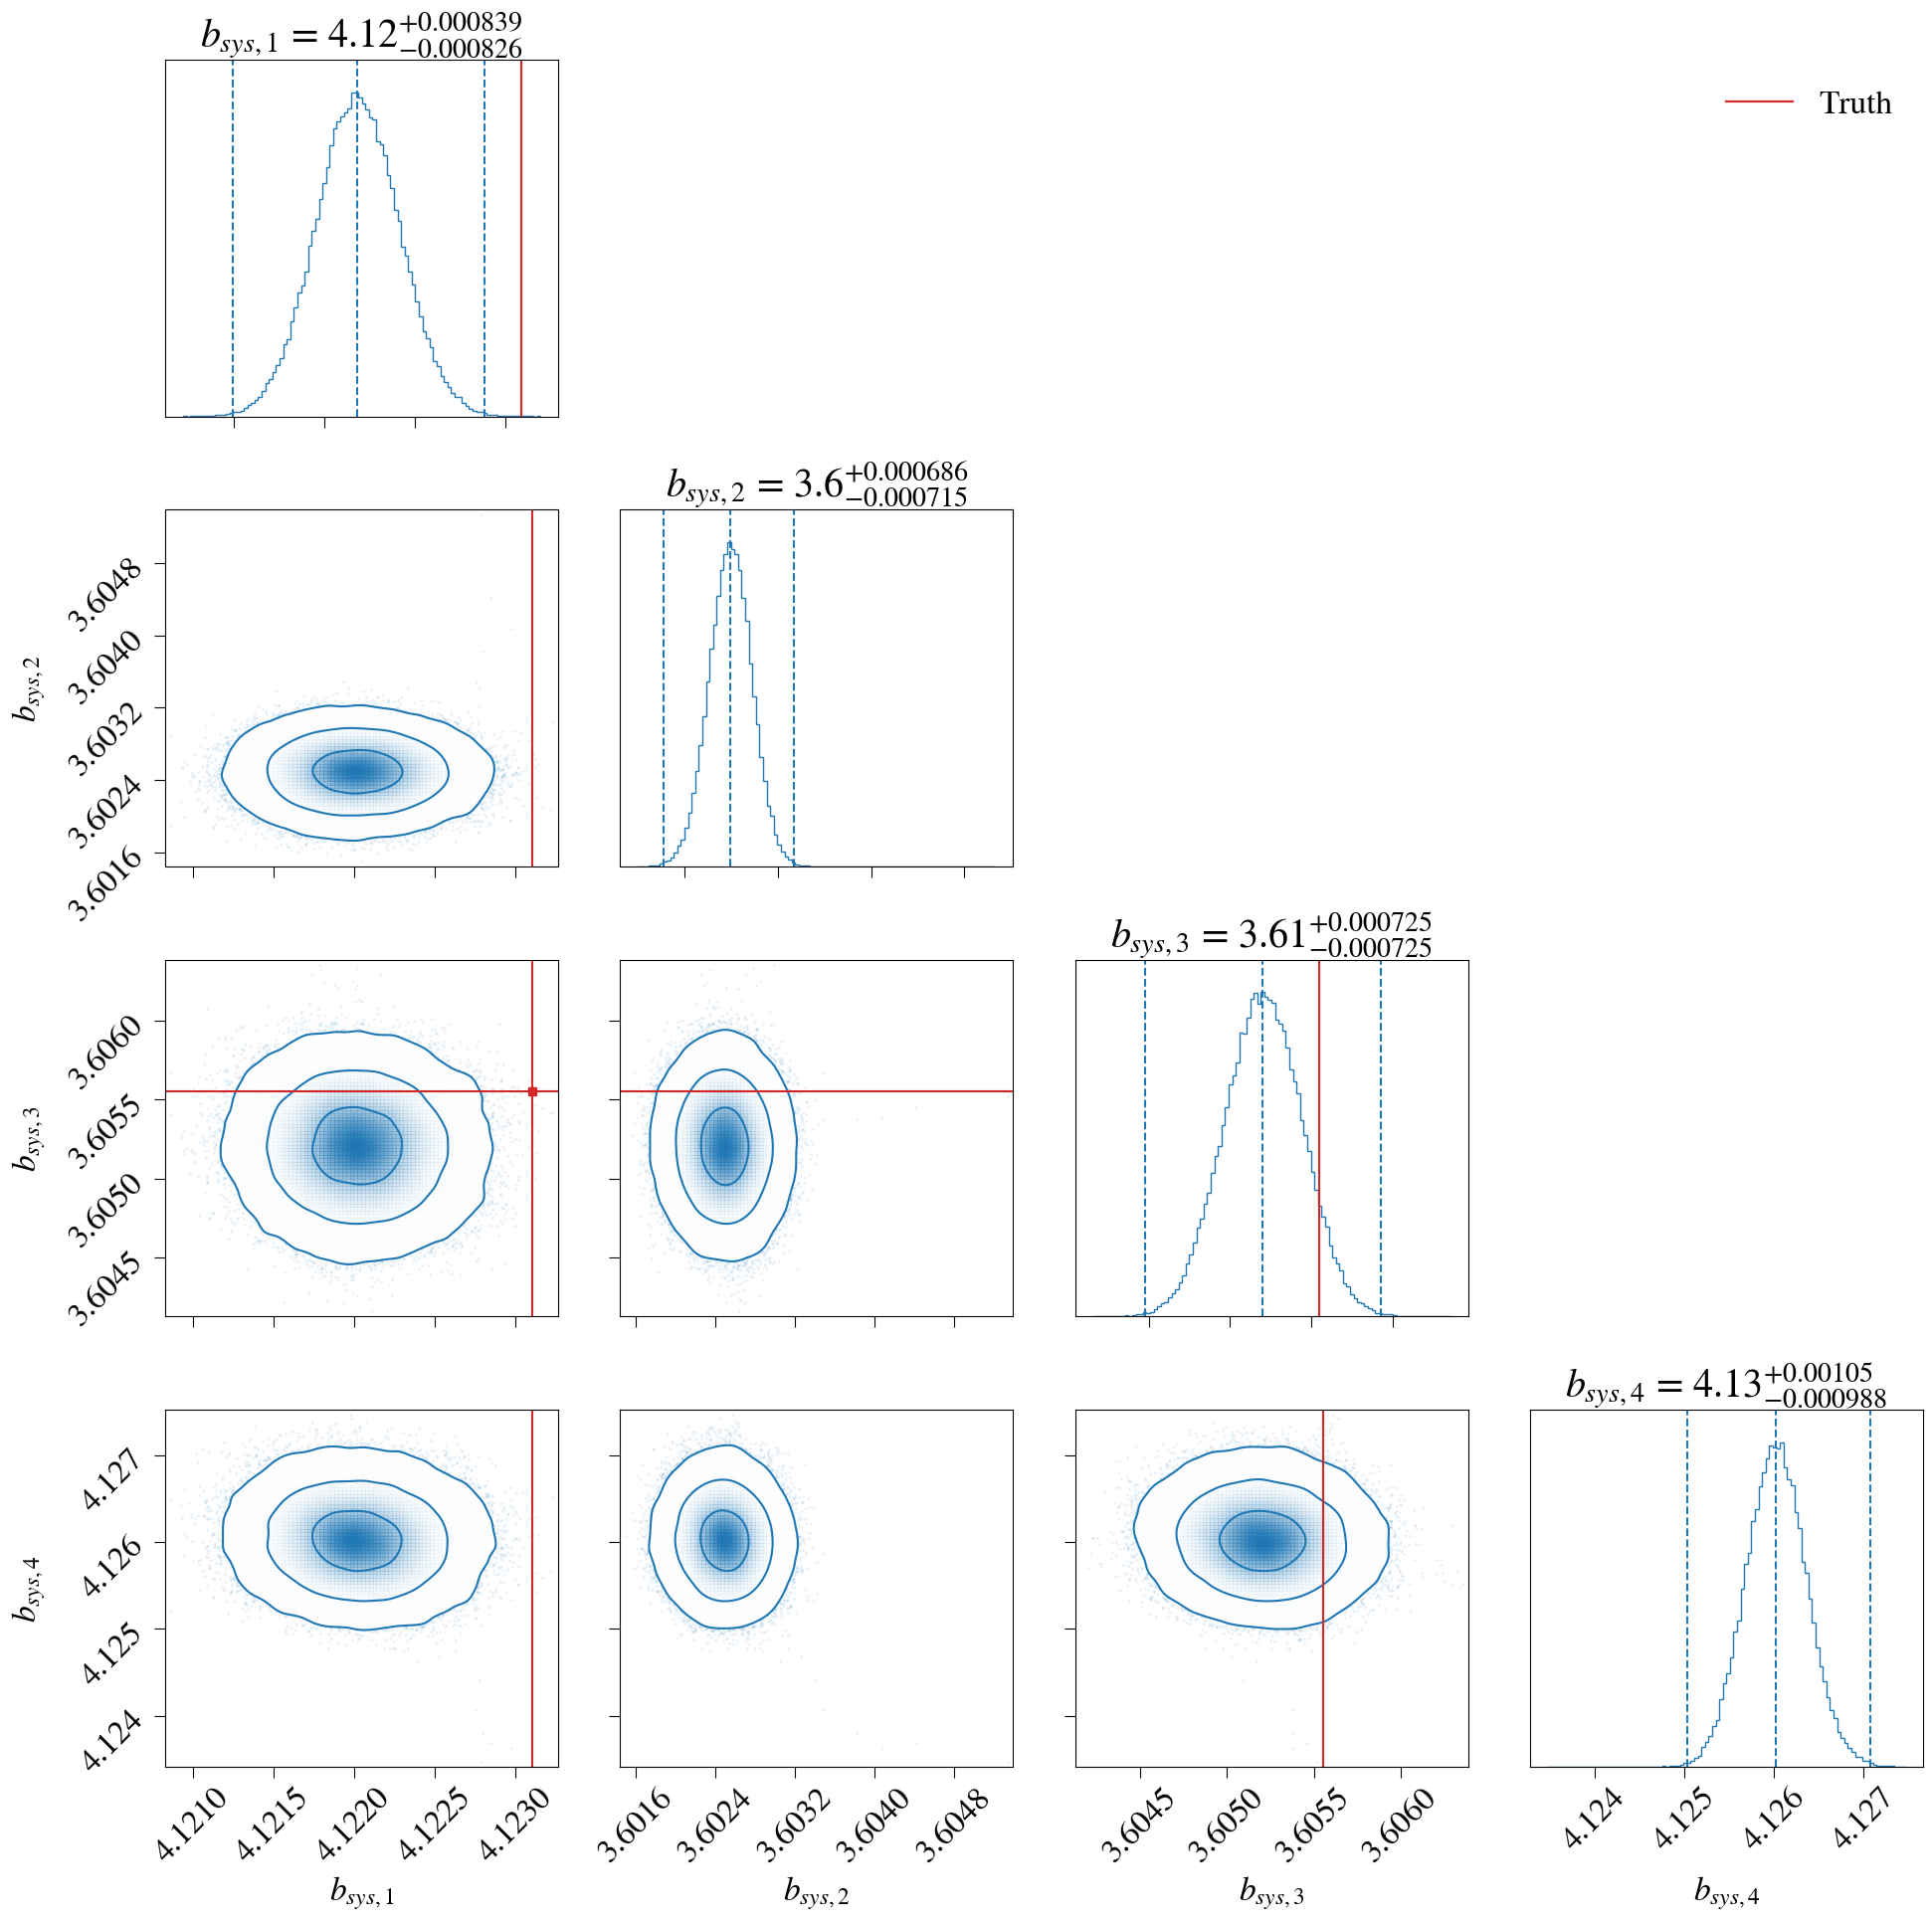

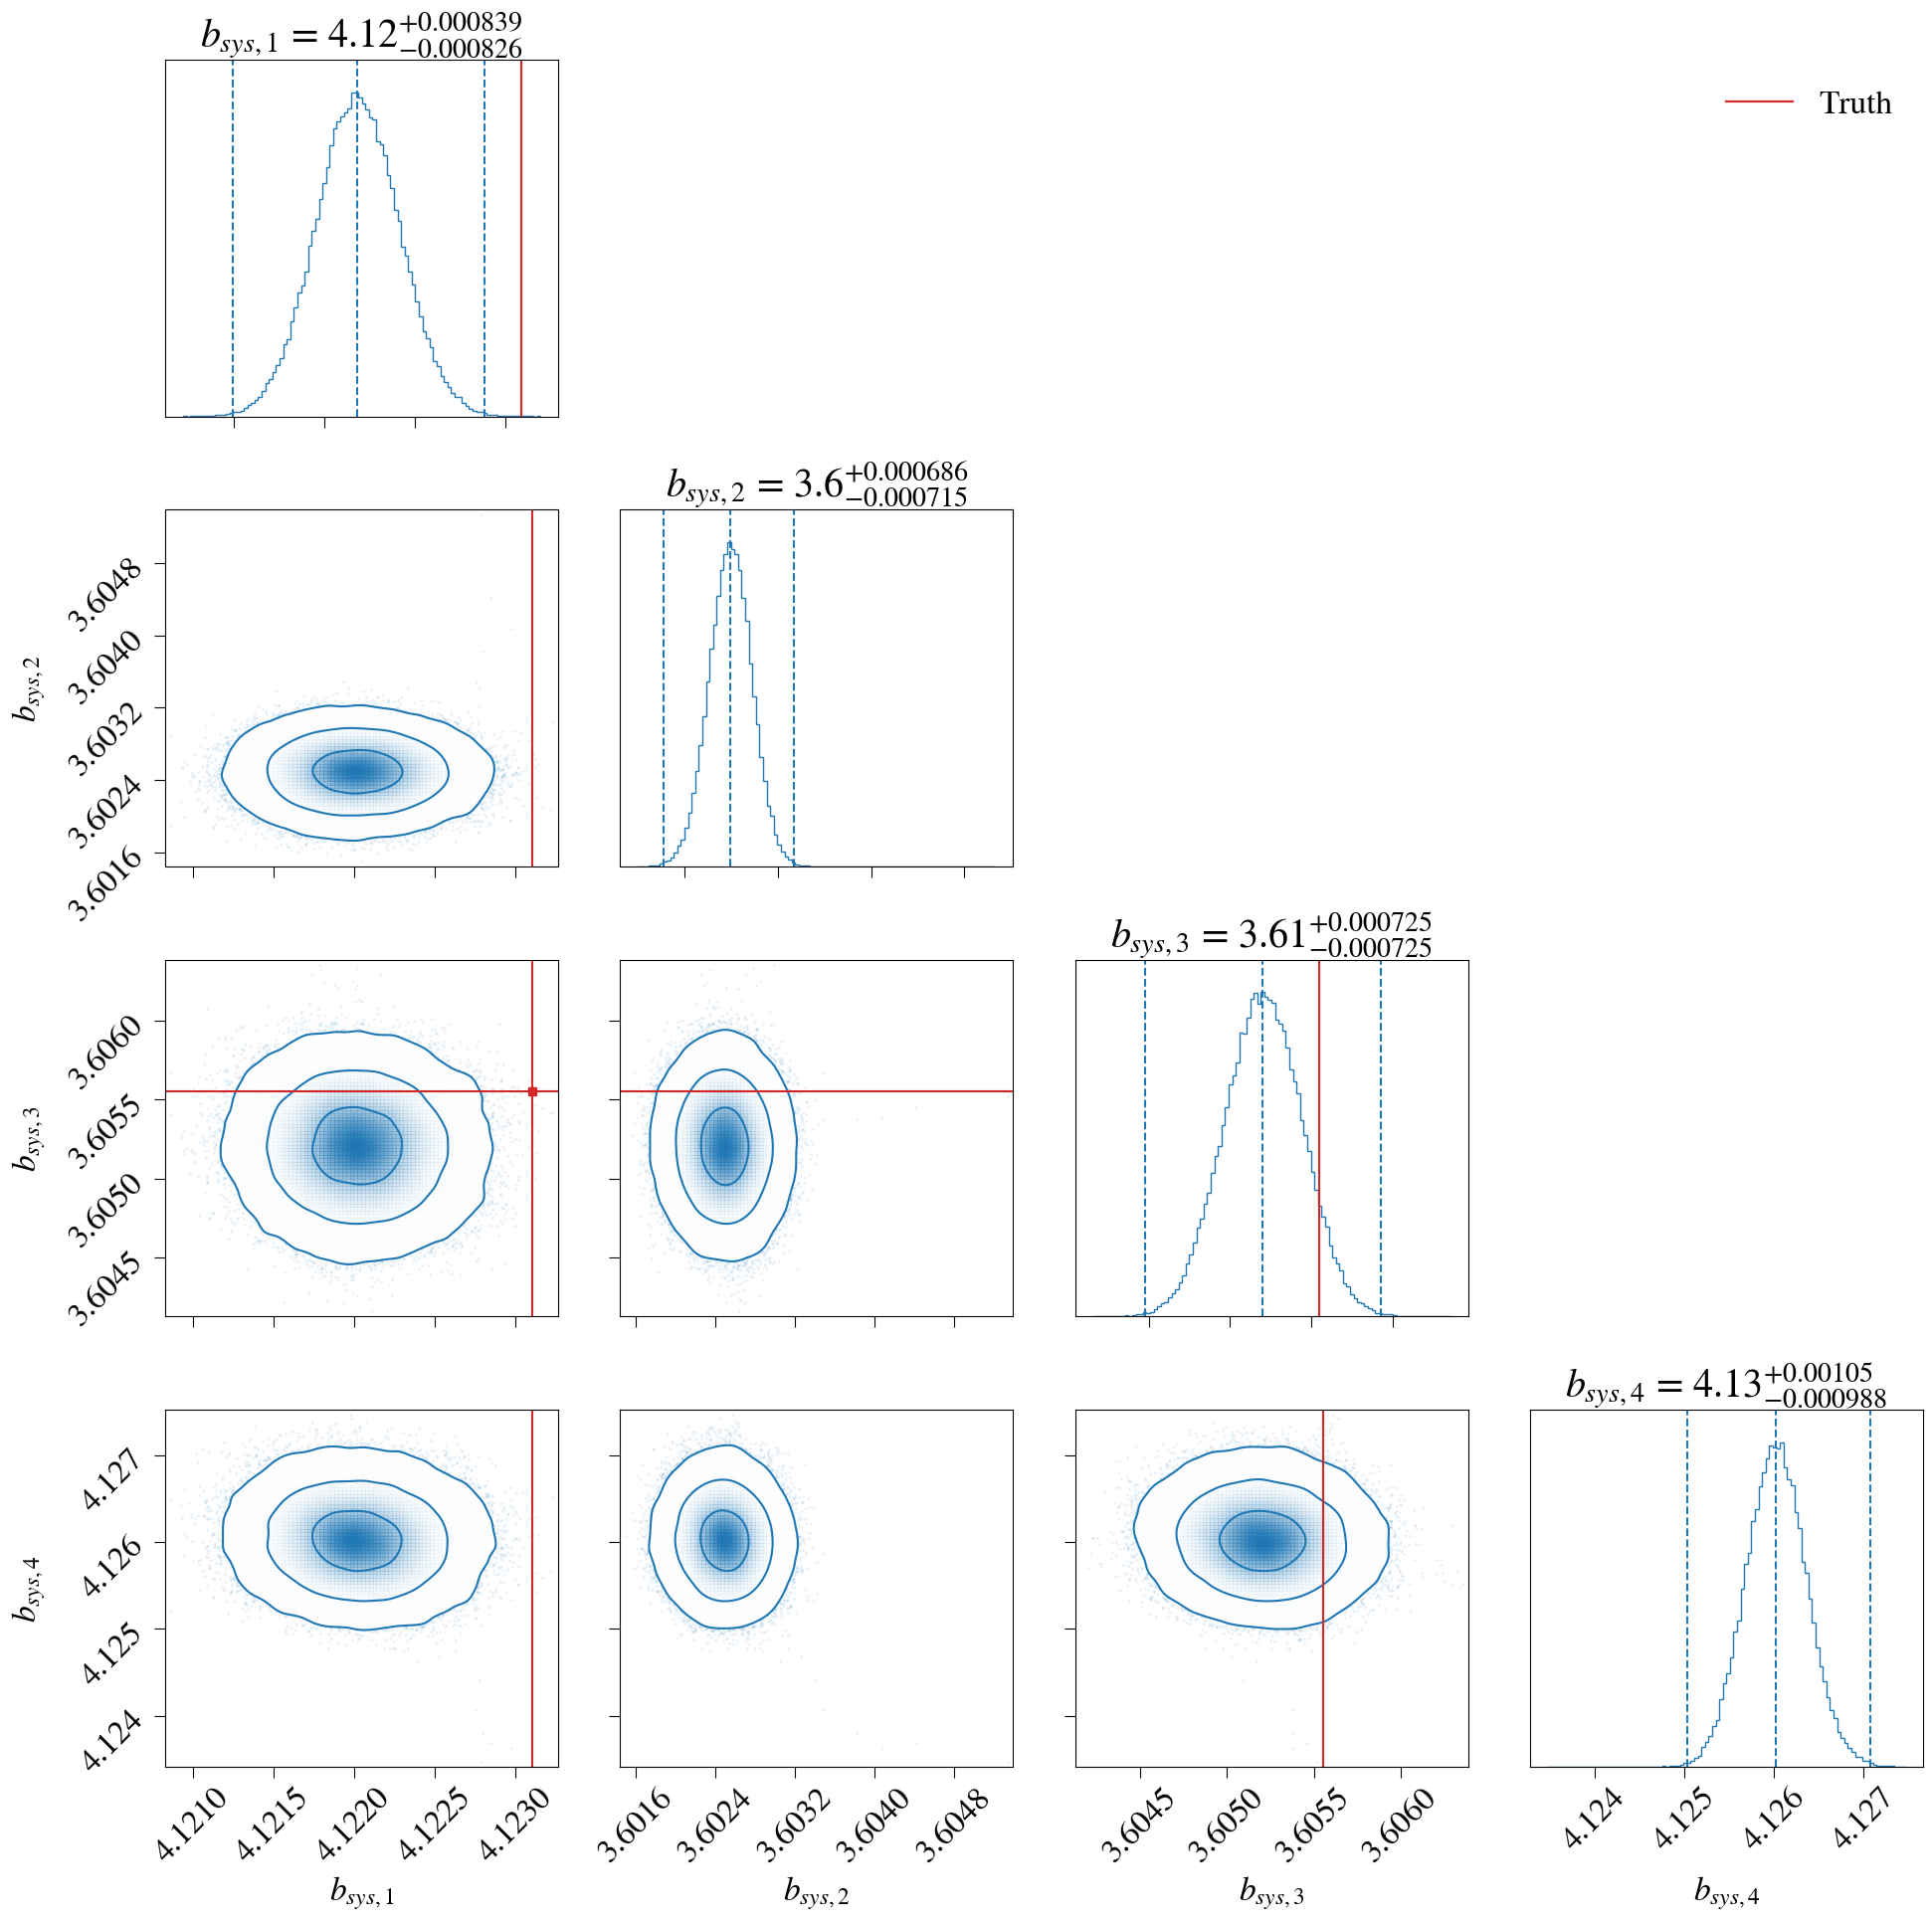

In [110]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
for a in ax.flatten():
    a.tick_params(length=8)
corner_plot(
    np.abs(b_sys_gcr),
    truths=np.abs(sys_amps_true),
    labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'],
    fig=fig,
    nsigma=3,
)
# plt.savefig(fig_dir + '/bsys_corner_plot.pdf', bbox_inches='tight', dpi=300)

---
# Figure 9: Systematics fractional error (single case)

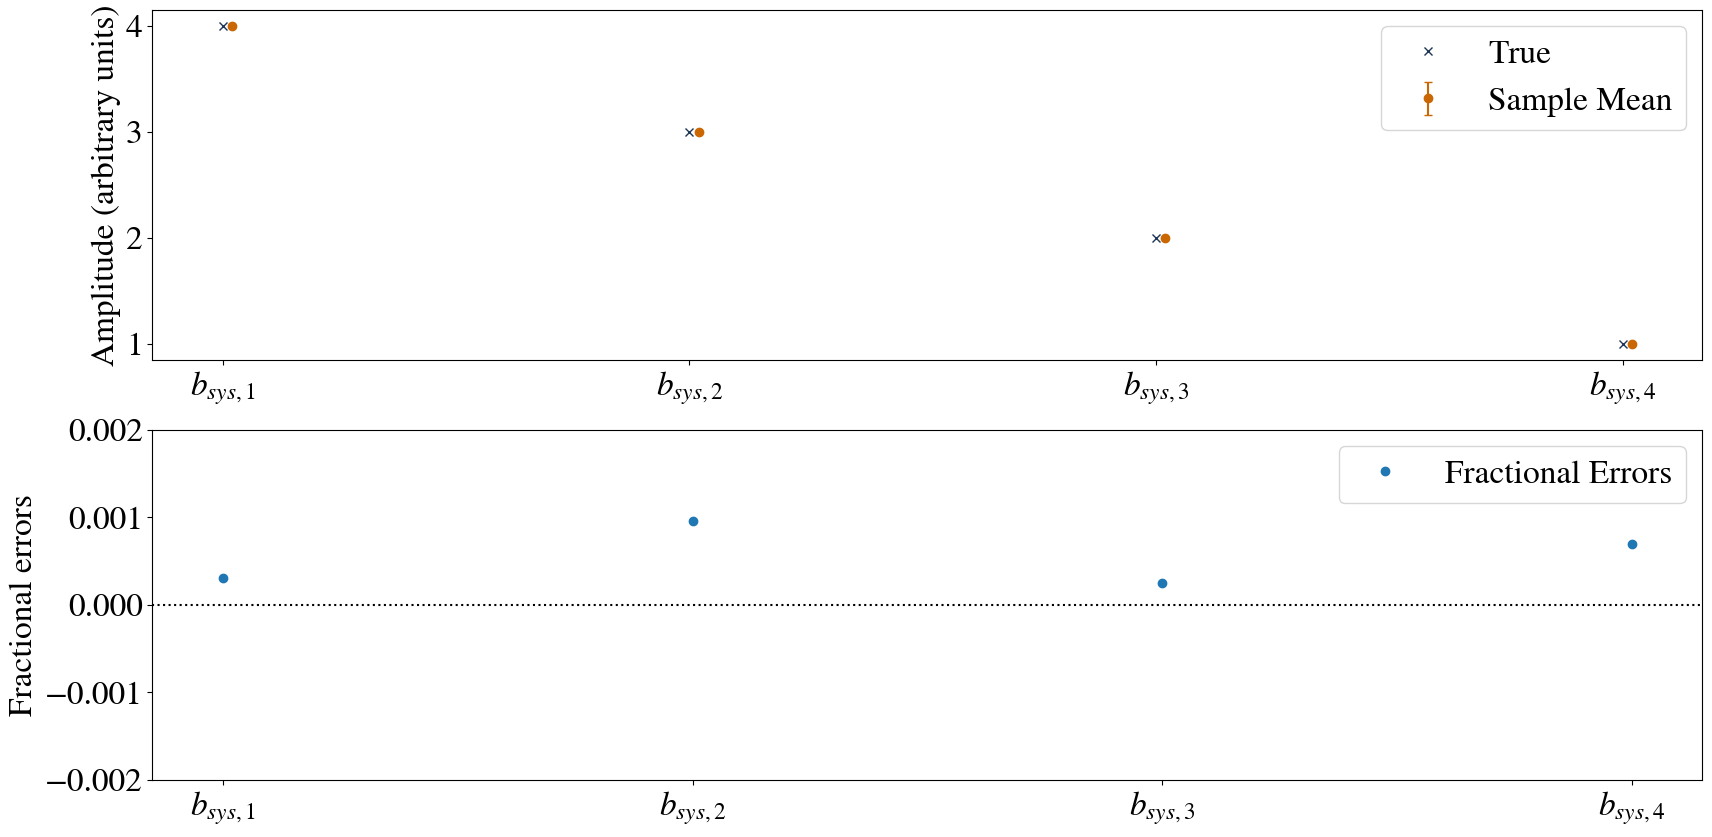

In [68]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

errs = np.vstack((
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
))

ax[0].plot(np.imag(sys_amps_true), 'x', c=colors[0], label='True')
ax[0].errorbar(
    [0.02, 1.02, 2.02, 3.02], np.imag(b_sys_gcr.mean(axis=0)),
    fmt='o', yerr=errs, label='Sample Mean', capsize=3, c=colors[1],
)
ax[0].set_ylabel('Amplitude (arbitrary units)')
ax[0].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[0].legend()

res_mean = np.abs(sys_amps_true - b_sys_gcr.mean(axis=0)) / np.abs(sys_amps_true)
ax[1].plot([0, 1, 2, 3], res_mean, 'o', label='Fractional Errors')
ax[1].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[1].axhline(0, c='k', ls='dotted')
ax[1].set_ylabel('Fractional errors')
ax[1].set_ylim(-0.002, 0.002)
ax[1].legend()
# plt.savefig(fig_dir + '/sys_frac_error.pdf', bbox_inches='tight', dpi=300)

---
# Figure 10: Delay power spectrum (single case)

Max fractional error: 10.651628602881544


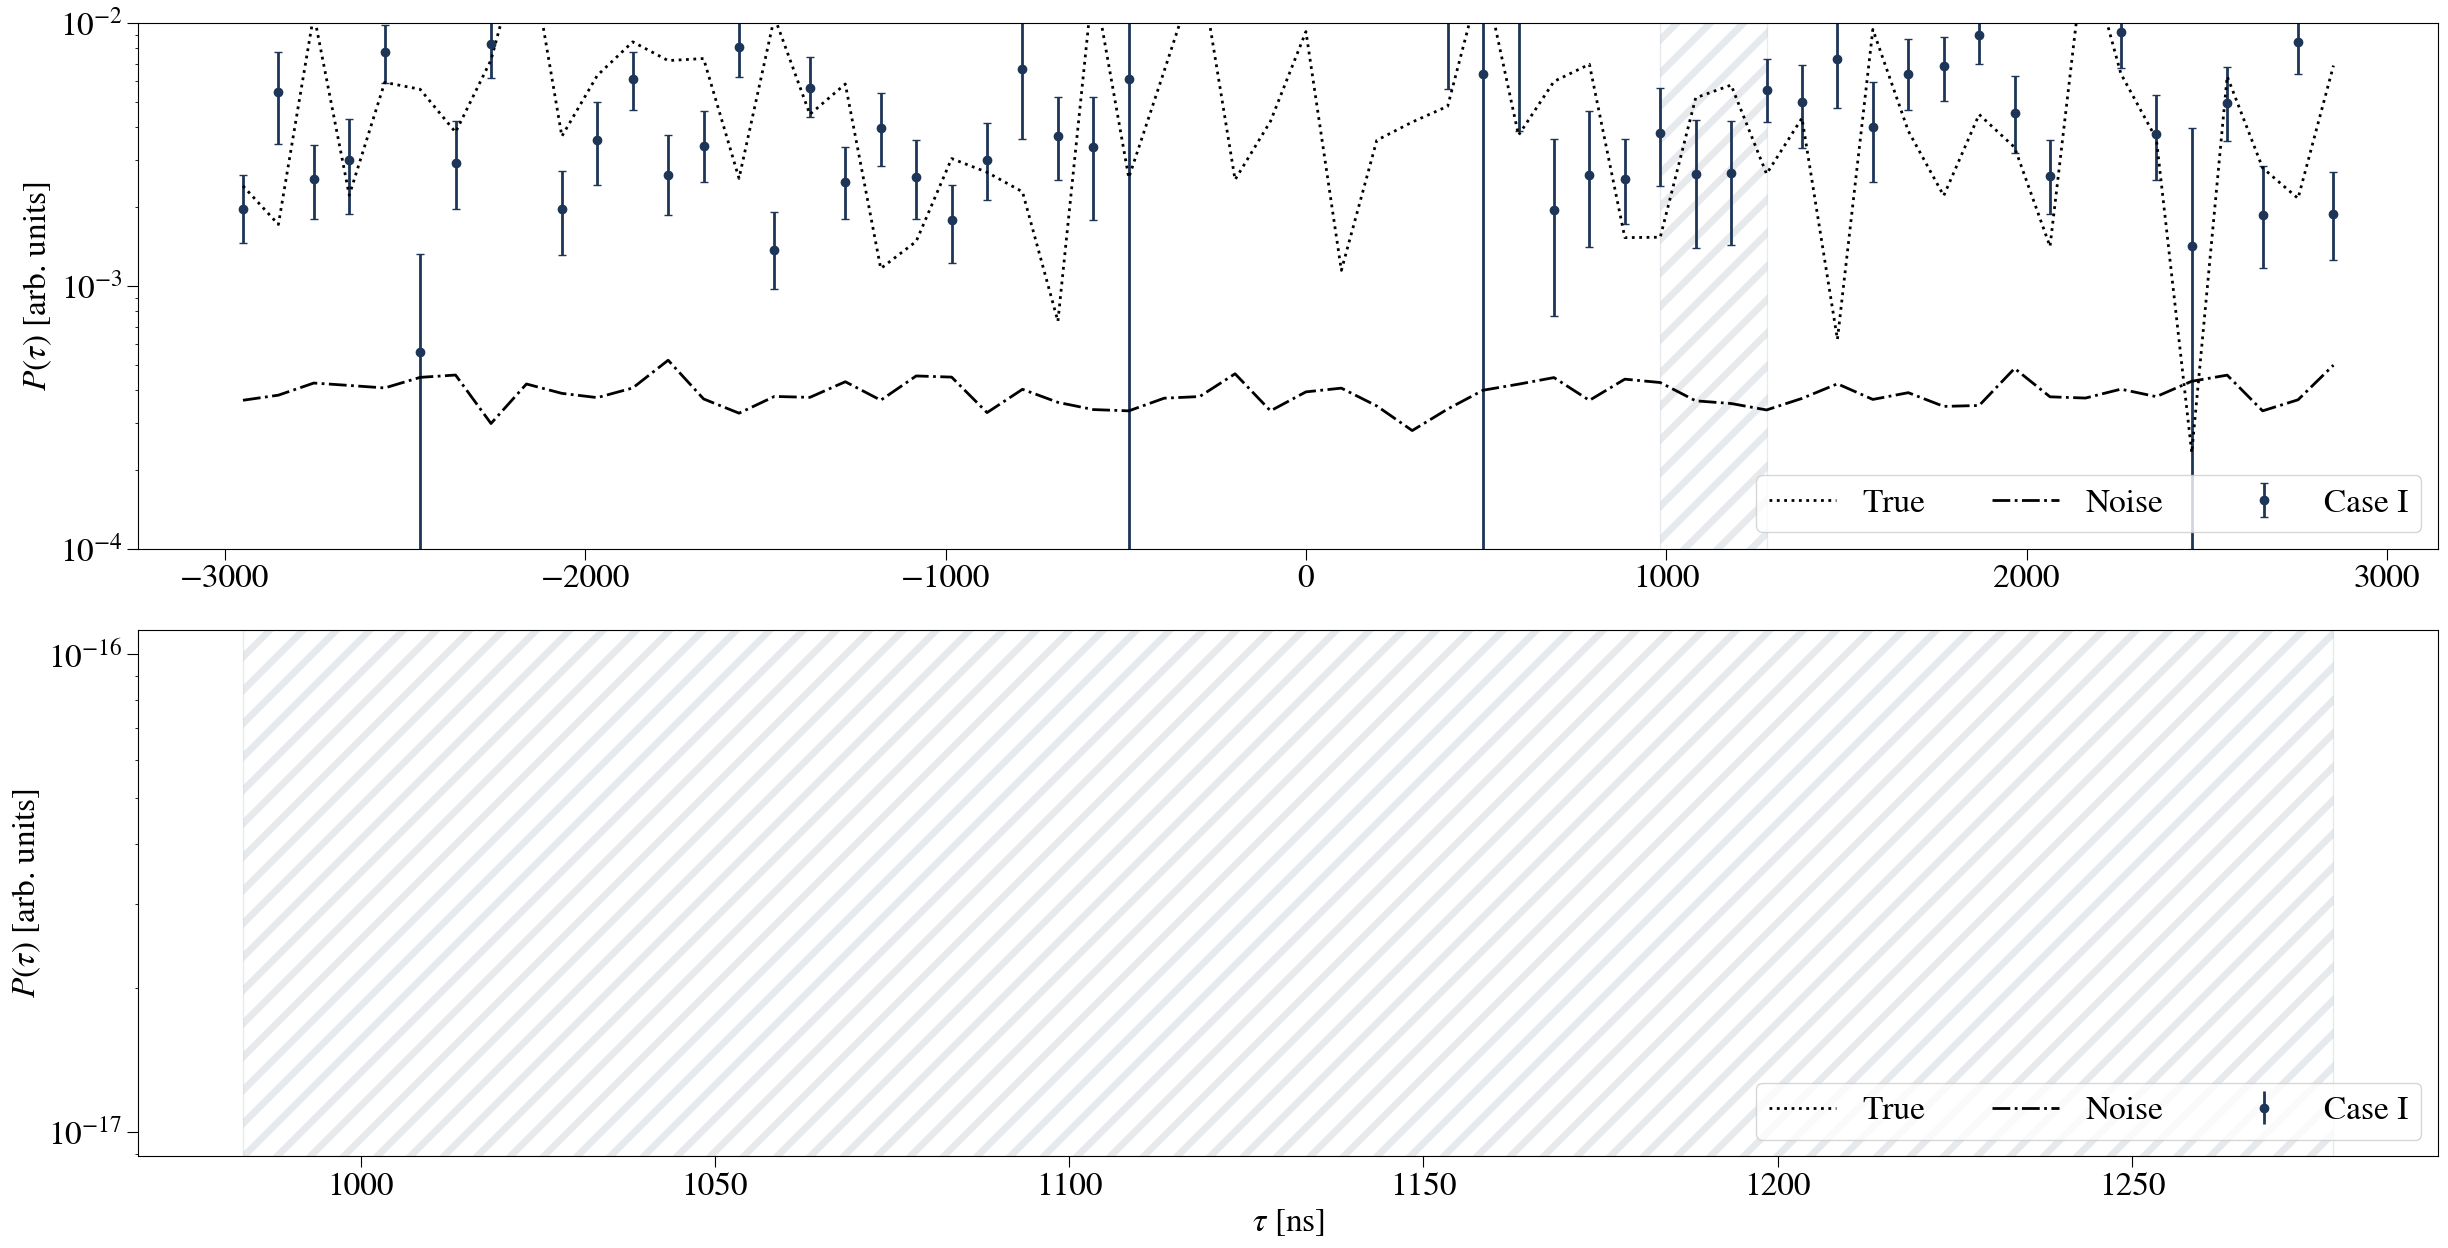

In [69]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

sys_delays = delays[np.unique(dl_inds[case_idx]) + int(Nfreqs / 2)].value

ps_sample_plot = ps_sample[Nburn:] if Nburn > 0 else ps_sample
ln_post_plot   = ln_post[Nburn:]   if Nburn > 0 else ln_post

dps_pwm    = np.average(ps_sample_plot, weights=ln_post_plot, axis=0)
percentile = conf_interval / 2 + 50
dps_ubound = np.percentile(ps_sample_plot, percentile,       axis=0)
dps_lbound = np.percentile(ps_sample_plot, 100 - percentile, axis=0)
dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

ax[0].errorbar(
    delays.value, dps_pwm, yerr=np.abs(dps_err),
    color=colors[0], ls='', marker='o', elinewidth=2, capsize=3, label=case_labels_v2[0],
)

x0, x1 = np.min(sys_delays), np.max(sys_delays)
ax[0].axvspan(x0, x1, facecolor='none', ec=colors[0], hatch='/', hatch_linewidth=5, alpha=0.1, zorder=0.1)
ax[1].axvspan(x0, x1, facecolor='none', ec=colors[0], hatch='/', hatch_linewidth=5, alpha=0.1, zorder=0.1)

ax[1].errorbar(
    delays[70:110].value, dps_pwm[70:110], yerr=np.abs(dps_err[:, 70:110]),
    color=colors[0], ls='', marker='o', elinewidth=2, capsize=3, label=case_labels_v2[0],
)
print('Max fractional error:', max((dps_pwm - eor_pspec_true) / eor_pspec_true))

ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].axhline(0, ls='dotted')
ax[1].plot(delays[70:110], eor_pspec_true[70:110], 'k:', label='True', lw=2)
ax[1].plot(delays[70:110], calc_ps(n.T)[70:110], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3)
ax[1].set_yscale('log')

ax[0].plot(delays, eor_pspec_true, 'k:', label='True', lw=2)
ax[0].plot(delays, calc_ps(n.T), 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-2)
ax[0].set_yscale('log')

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()
# plt.savefig(fig_dir + '/delay_power_spectrum_combined.pdf', bbox_inches='tight', dpi=300)

---
# Table 1: ESS and autocorrelation time

In [38]:
print('Case:', run_version)
taus = emcee.autocorr.integrated_time(b_sys_gcr, c=5, tol=50, quiet=True, has_walkers=False)
ess  = Niter / taus
print('\n Taus: {}\nEss:{}\n'.format(taus, ess))

Case: full_data_high_dl_fr_0

 Taus: [8.29288249 9.15409241 8.061103   8.93338042]
Ess:[1205.85333402 1092.40758729 1240.52502552 1119.39708479]



---
# Figure 11: FG–systematics correlation (single case)

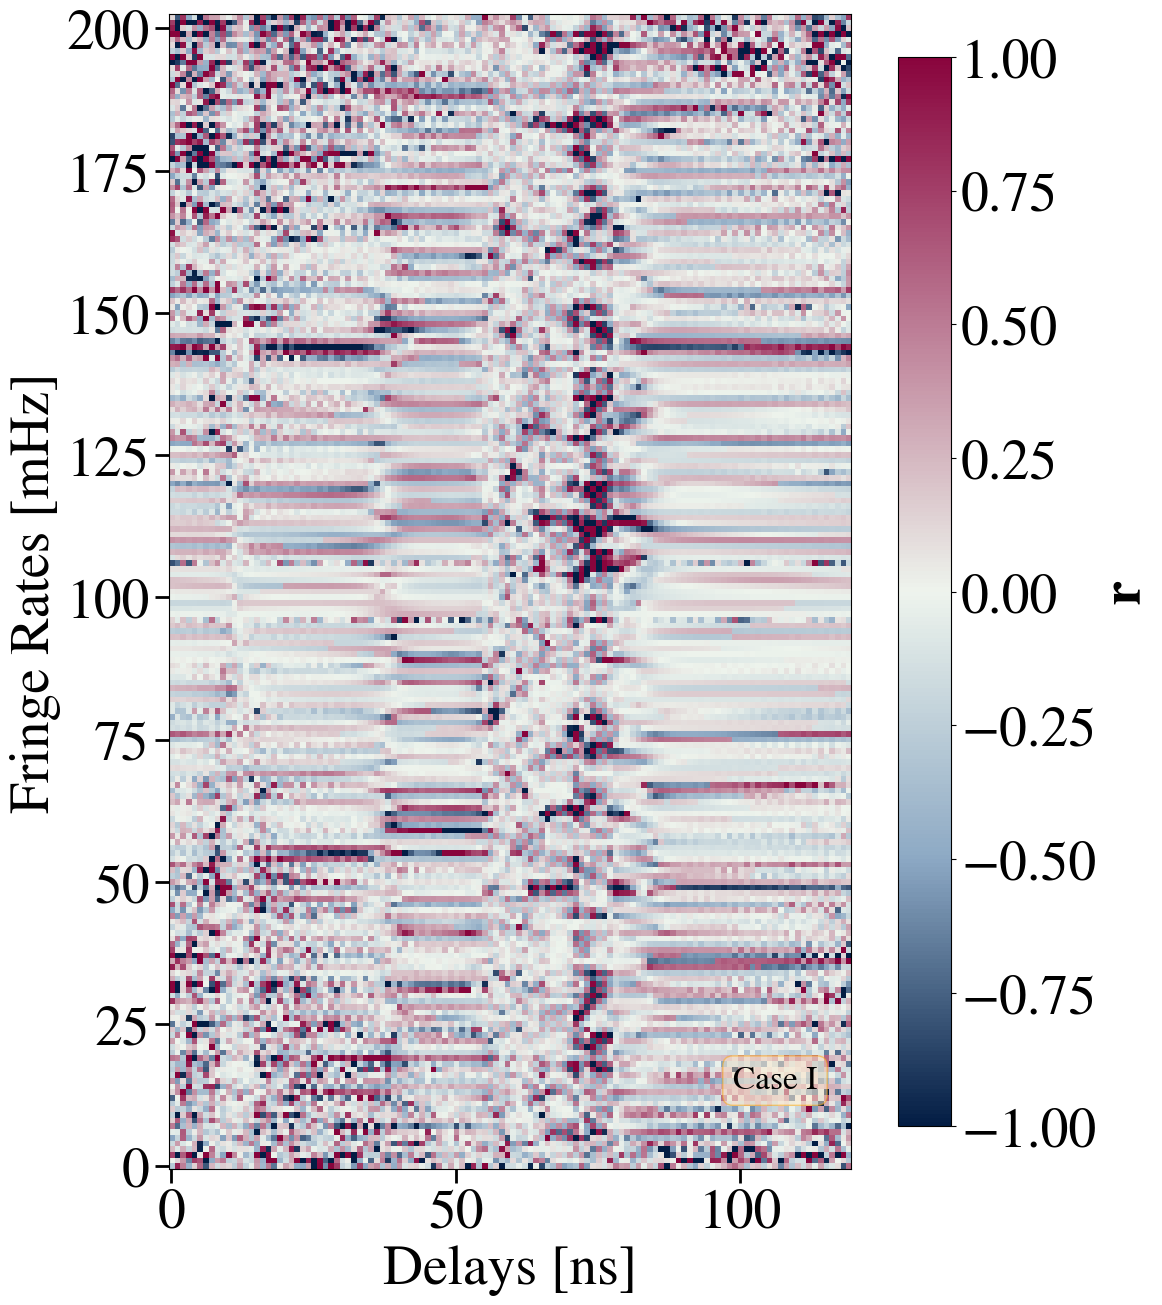

In [40]:
fig, axs = plt.subplots(1, 1, figsize=(15, 15))

im = axs.imshow(corr_maps[0][::-1, :].real, cmap=paper_map, origin='lower', vmin=-1, vmax=1)
axs.text(0.95, 0.07, case_labels_v2[0], bbox=bbox,
         transform=axs.transAxes, horizontalalignment='right')

cbar = plt.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
cbar.set_label(r'$\mathbf{r}$', size=40)
cbar.ax.tick_params(labelsize=40)

axs.set_xlabel('Delays [ns]', fontsize=40)
axs.set_ylabel('Fringe Rates [mHz]', fontsize=40)
axs.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=40)
# axs.set_xticks(xticklocs, labels=xticklabels_dl, rotation=15)
# axs.set_yticks(yticklocs, labels=yticklabels_fr)

# plt.savefig(fig_dir + '/fg_sys._corr.pdf', bbox_inches='tight', dpi=300)

In [41]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s")

Total notebook runtime: 00h 07m 29.3s
